---

# Business Case: Delhivery - Feature Engineering  

**Prathik Cherian** (Batch: DSML Sep '24)

---

## Data Cleaning and EDA

In [1]:
# importing the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# importing the dataset
df = pd.read_csv('delhivery_data.csv')

Inspecting the data set:

In [3]:
df.shape

(144867, 24)

In [4]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [5]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


Checking for nulls:

In [6]:
# calculating the percentage of missing values in each column
100*df.isna().sum()/len(df)

data                              0.000000
trip_creation_time                0.000000
route_schedule_uuid               0.000000
route_type                        0.000000
trip_uuid                         0.000000
source_center                     0.000000
source_name                       0.202254
destination_center                0.000000
destination_name                  0.180165
od_start_time                     0.000000
od_end_time                       0.000000
start_scan_to_end_scan            0.000000
is_cutoff                         0.000000
cutoff_factor                     0.000000
cutoff_timestamp                  0.000000
actual_distance_to_destination    0.000000
actual_time                       0.000000
osrm_time                         0.000000
osrm_distance                     0.000000
factor                            0.000000
segment_actual_time               0.000000
segment_osrm_time                 0.000000
segment_osrm_distance             0.000000
segment_fac

> Dropping the null values as they are extremely few and insignificant in number.

In [7]:
df.dropna(axis=0, inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(144316, 24)

Checking for duplicates:

In [8]:
df.duplicated().sum()

np.int64(0)

> There are no duplicate records in the data set.

Dropping unwanted/unknown columns:

In [9]:
cols = 'is_cutoff cutoff_factor cutoff_timestamp factor segment_factor'.split()
df.drop(columns=cols, inplace=True)
df.shape

(144316, 19)

Converting timestamp columns to pandas datetime dtype:

In [10]:
time_cols = 'trip_creation_time od_start_time od_end_time'.split()
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

> Time frame of data:

In [11]:
(
    df['trip_creation_time'].min(),  # earliest trip creation time
    df['od_end_time'].max(),  # latest end time
    # total time span covered by the dataset
    df['od_end_time'].max()-df['trip_creation_time'].min()
)

(Timestamp('2018-09-12 00:00:16.535741'),
 Timestamp('2018-10-08 03:00:24.353479'),
 Timedelta('26 days 03:00:07.817738'))

The data we have is for about 26 days from 2018-09-12 to 2018-10-09. 

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_creation_time,144316,2018-09-22 13:05:09.454117120,2018-09-12 00:00:16.535741,2018-09-17 02:46:11.004421120,2018-09-22 03:36:19.186585088,2018-09-27 17:53:19.027942912,2018-10-03 23:59:42.701692,NaN
od_start_time,144316,2018-09-22 17:32:42.435769344,2018-09-12 00:00:16.535741,2018-09-17 07:37:35.014584832,2018-09-22 07:35:23.038482944,2018-09-27 22:01:30.861209088,2018-10-06 04:27:23.392375,NaN
od_end_time,144316,2018-09-23 09:36:54.057172224,2018-09-12 00:50:10.814399,2018-09-18 01:29:56.978912,2018-09-23 02:49:00.936600064,2018-09-28 12:13:41.675546112,2018-10-08 03:00:24.353479,NaN
start_scan_to_end_scan,144316.0,963.697698,20.0,161.0,451.0,1645.0,7898.0,1038.082976
actual_distance_to_destination,144316.0,234.708498,9.000045,23.352027,66.135322,286.919294,1927.447705,345.480571
actual_time,144316.0,417.996237,9.0,51.0,132.0,516.0,4532.0,598.940065
osrm_time,144316.0,214.437055,6.0,27.0,64.0,259.0,1686.0,308.448543
osrm_distance,144316.0,285.549785,9.0082,29.89625,78.6244,346.3054,2326.1991,421.717826
segment_actual_time,144316.0,36.175379,-244.0,20.0,28.0,40.0,3051.0,53.524298
segment_osrm_time,144316.0,18.495697,0.0,11.0,17.0,22.0,1611.0,14.774008


In [13]:
df.describe(include='object').T

,count,unique,top,freq
data,144316,2,training,104632
route_schedule_uuid,144316,1497,thanos::sroute:4029a8a2-6c74-4b7e-a6d8-f9e069f...,1812
route_type,144316,2,FTL,99132
trip_uuid,144316,14787,trip-153837029526866991,101
source_center,144316,1496,IND000000ACB,23267
source_name,144316,1496,Gurgaon_Bilaspur_HB (Haryana),23267
destination_center,144316,1466,IND000000ACB,15192
destination_name,144316,1466,Gurgaon_Bilaspur_HB (Haryana),15192


In [14]:
# inspecting the columns with categorical data

for col in df.select_dtypes('object').columns:
    print(f"{col}:{df[col].nunique()}")
    display(df[col].unique())

data:2


array(['training', 'test'], dtype=object)

route_schedule_uuid:1497


array(['thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3297ef',
       'thanos::sroute:ff52ef7a-4d0d-4063-9bfe-cc211728881b',
       'thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d315e6', ...,
       'thanos::sroute:72cf9feb-f4e3-4a55-b92a-0b686ee8fabc',
       'thanos::sroute:5e08be79-8a4c-4a91-a514-5350403c0e31',
       'thanos::sroute:a3c30562-87e5-471c-9646-0ed49c150996'],
      shape=(1497,), dtype=object)

route_type:2


...

array(['Anand_VUNagar_DC (Gujarat)', 'Khambhat_MotvdDPP_D (Gujarat)',
       'Bhiwandi_Mankoli_HB (Maharashtra)', ...,
       'Dwarka_StnRoad_DC (Gujarat)', 'Bengaluru_Nelmngla_L (Karnataka)',
       'Kulithalai_AnnaNGR_D (Tamil Nadu)'], shape=(1496,), dtype=object)

destination_center:1466


array(['IND388620AAB', 'IND388320AAA', 'IND411033AAA', ...,
       'IND600004AAA', 'IND134203AAA', 'IND400701AAA'],
      shape=(1466,), dtype=object)

destination_name:1466


array(['Khambhat_MotvdDPP_D (Gujarat)', 'Anand_Vaghasi_IP (Gujarat)',
       'Pune_Tathawde_H (Maharashtra)', ...,
       'Chennai_Mylapore (Tamil Nadu)', 'Naraingarh_Ward2DPP_D (Haryana)',
       'Mumbai_Ghansoli_DC (Maharashtra)'], shape=(1466,), dtype=object)

We can convert some of these object fields to category dtype to further optimize memory usage:

In [15]:
obj_cols = df.select_dtypes('object').columns
for col in obj_cols:
    if col not in ['trip_uuid', 'source_center', 'destination_center']:
        df[col] = df[col].astype('category')
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144316 entries, 0 to 144315
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144316 non-null  category      
 1   trip_creation_time              144316 non-null  datetime64[ns]
 2   route_schedule_uuid             144316 non-null  category      
 3   route_type                      144316 non-null  category      
 4   trip_uuid                       144316 non-null  object        
 5   source_center                   144316 non-null  object        
 6   source_name                     144316 non-null  category      
 7   destination_center              144316 non-null  object        
 8   destination_name                144316 non-null  category      
 9   od_start_time                   144316 non-null  datetime64[ns]
 10  od_end_time                     144316 non-null  datetim

We have reduced the memory usage by about 70% (from 130mb to 40mb)!!

Creating `segment_key` which is a combination of `trip_uuid`, `source_center` and `destination_center`:

In [16]:
df['segment_key'] = df['trip_uuid'] + '_' + \
    df['source_center'] + '_' + df['destination_center']
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_key
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,10.435660,14.0,11.0,11.9653,14.0,11.0,11.9653,trip-153741093647649320_IND388121AAA_IND388620AAB
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,18.936842,24.0,20.0,21.7243,10.0,9.0,9.7590,trip-153741093647649320_IND388121AAA_IND388620AAB
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,27.637279,40.0,28.0,32.5395,16.0,7.0,10.8152,trip-153741093647649320_IND388121AAA_IND388620AAB
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,36.118028,62.0,40.0,45.5620,21.0,12.0,13.0224,trip-153741093647649320_IND388121AAA_IND388620AAB
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,39.386040,68.0,44.0,54.2181,6.0,5.0,3.9153,trip-153741093647649320_IND388121AAA_IND388620AAB


Creating cumulative sums for `segment_actual_time`, `segment_osrm_distance`, `segment_osrm_time` columns:

In [17]:
cum_cols = 'segment_actual_time segment_osrm_distance segment_osrm_time'.split()

for col in cum_cols:
    df[col + '_sum'] = df.groupby('segment_key')[col].cumsum()

# inspecting the cumulative columns
df[[col for col in cum_cols]+[col + '_sum' for col in cum_cols]].head()

,segment_actual_time,segment_osrm_distance,segment_osrm_time,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,14.0,11.9653,11.0,14.0,11.9653,11.0
1,10.0,9.7590,9.0,24.0,21.7243,20.0
2,16.0,10.8152,7.0,40.0,32.5395,27.0
3,21.0,13.0224,12.0,61.0,45.5619,39.0
4,6.0,3.9153,5.0,67.0,49.4772,44.0


We now create a dictionary specifying the aggregating function for each relevant column in `df` when we group by using `segment_key`.

In [18]:
create_segment_dict = {

    'data': 'first',
    'trip_creation_time': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',

    'source_center': 'first',
    'source_name': 'first',
    'destination_center': 'last',
    'destination_name': 'last',

    'od_start_time': 'first',
    'od_end_time': 'first',

    'start_scan_to_end_scan': 'first',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',

    'osrm_time': 'last',
    'osrm_distance': 'last',

    'segment_actual_time_sum': 'last',
    'segment_osrm_distance_sum': 'last',
    'segment_osrm_time_sum': 'last',

}

Grouping by `segment_key` and using the above `create_segment_dict` for aggregation:

In [19]:
segment_df = df.groupby('segment_key').agg(create_segment_dict).reset_index(
).sort_values(by=['segment_key', 'od_end_time'], ascending=True)
segment_df

,segment_key,data,trip_creation_time,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,trip-153671041653548748_IND209304AAA_IND000000ACB,training,2018-09-12 00:00:16.535741,FTL,trip-153671041653548748,IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,1260.0,383.759164,732.0,329.0,446.5496,728.0,670.6205,534.0
1,trip-153671041653548748_IND462022AAA_IND209304AAA,training,2018-09-12 00:00:16.535741,FTL,trip-153671041653548748,IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),IND209304AAA,Kanpur_Central_H_6 (Uttar Pradesh),2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,999.0,440.973689,830.0,388.0,544.8027,820.0,649.8528,474.0
2,trip-153671042288605164_IND561203AAB_IND562101AAA,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),IND562101AAA,Chikblapur_ShntiSgr_D (Karnataka),2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,58.0,24.644021,47.0,26.0,28.1994,46.0,28.1995,26.0
3,trip-153671042288605164_IND572101AAA_IND561203AAB,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,IND572101AAA,Tumkur_Veersagr_I (Karnataka),IND561203AAB,Doddablpur_ChikaDPP_D (Karnataka),2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,122.0,48.542890,96.0,42.0,56.9116,95.0,55.9899,39.0
4,trip-153671043369099517_IND000000ACB_IND160002AAC,training,2018-09-12 00:00:33.691250,FTL,trip-153671043369099517,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,834.0,237.439610,611.0,212.0,281.2109,608.0,317.7408,231.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26217,trip-153861115439069069_IND628204AAA_IND627657AAA,test,2018-10-03 23:59:14.390954,Carting,trip-153861115439069069,IND628204AAA,Tirchchndr_Shnmgprm_D (Tamil Nadu),IND627657AAA,Thisayanvilai_UdnkdiRD_D (Tamil Nadu),2018-10-04 02:29:04.272194,2018-10-04 03:31:11.183797,62.0,33.627182,51.0,41.0,42.5213,49.0,42.1431,42.0
26218,trip-153861115439069069_IND628613AAA_IND627005AAA,test,2018-10-03 23:59:14.390954,Carting,trip-153861115439069069,IND628613AAA,Peikulam_SriVnktpm_D (Tamil Nadu),IND627005AAA,Tirunelveli_VdkkuSrt_I (Tamil Nadu),2018-10-04 04:16:39.894872,2018-10-04 05:47:45.162682,91.0,33.673835,90.0,48.0,40.6080,89.0,78.5869,77.0
26219,trip-153861115439069069_IND628801AAA_IND628204AAA,test,2018-10-03 23:59:14.390954,Carting,trip-153861115439069069,IND628801AAA,Eral_Busstand_D (Tamil Nadu),IND628204AAA,Tirchchndr_Shnmgprm_D (Tamil Nadu),2018-10-04 01:44:53.808000,2018-10-04 02:29:04.272194,44.0,12.661945,30.0,14.0,16.0185,29.0,16.0184,14.0
26220,trip-153861118270144424_IND583119AAA_IND583101AAA,test,2018-10-03 23:59:42.701692,FTL,trip-153861118270144424,IND583119AAA,Sandur_WrdN1DPP_D (Karnataka),IND583101AAA,Bellary_Dc (Karnataka),2018-10-04 03:58:40.726547,2018-10-04 08:46:09.166940,287.0,40.546740,233.0,42.0,52.5303,233.0,52.5303,42.0


We create a new feature `od_time_diff_hour` which is the difference between `od_end_time` and `od_start_time` in hours.

In [20]:
segment_df['od_time_diff_hour'] = (
    segment_df['od_end_time'] - segment_df['od_start_time']
).dt.total_seconds() / (60)

Creating `create_trip_dict` to specify aggregation functions for each relevant column in `segment_df` when grouping by using `trip_uuid`:

In [21]:
create_trip_dict = {

    'data': 'first',
    'trip_creation_time': 'first',
    'route_type': 'first',
    'trip_uuid': 'first',

    # 'source_center': 'first',
    'source_name': 'first',
    # 'destination_center': 'last',
    'destination_name': 'last',

    'start_scan_to_end_scan': 'sum',
    'od_time_diff_hour': 'sum',
    'actual_distance_to_destination': 'sum',
    'actual_time': 'sum',

    'osrm_time': 'sum',
    'osrm_distance': 'sum',

    'segment_actual_time_sum': 'sum',
    'segment_osrm_distance_sum': 'sum',
    'segment_osrm_time_sum': 'sum',

}

We will now do the aggregation using `trip_uuid` to create a trip-wise summary of the data.

In [22]:
trip_df = segment_df.groupby('trip_uuid').agg(
    create_trip_dict).reset_index(drop=True)
trip_df

,data,trip_creation_time,route_type,trip_uuid,source_name,destination_name,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,training,2018-09-12 00:00:16.535741,FTL,trip-153671041653548748,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2259.0,2260.109800,824.732854,1562.0,717.0,991.3523,1548.0,1320.4733,1008.0
1,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),180.0,181.611874,73.186911,143.0,68.0,85.1110,141.0,84.1894,65.0
2,training,2018-09-12 00:00:33.691250,FTL,trip-153671043369099517,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),3933.0,3934.362520,1927.404273,3347.0,1740.0,2354.0665,3308.0,2545.2678,1941.0
3,training,2018-09-12 00:01:00.113710,Carting,trip-153671046011330457,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),100.0,100.494935,17.175274,59.0,15.0,19.6800,59.0,19.8766,16.0
4,training,2018-09-12 00:02:09.740725,FTL,trip-153671052974046625,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),717.0,718.349042,127.448500,341.0,117.0,146.7918,340.0,146.7919,115.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14782,test,2018-10-03 23:55:56.258533,Carting,trip-153861095625827784,Chandigarh_Mehmdpur_H (Punjab),Chandigarh_Mehmdpur_H (Punjab),257.0,258.028928,57.762332,83.0,62.0,73.4630,82.0,64.8551,62.0
14783,test,2018-10-03 23:57:23.863155,Carting,trip-153861104386292051,FBD_Balabhgarh_DPC (Haryana),Faridabad_Blbgarh_DC (Haryana),60.0,60.590521,15.513784,21.0,12.0,16.0882,21.0,16.0883,11.0
14784,test,2018-10-03 23:57:44.429324,Carting,trip-153861106442901555,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),421.0,422.119867,38.684839,282.0,48.0,58.9037,281.0,104.8866,88.0
14785,test,2018-10-03 23:59:14.390954,Carting,trip-153861115439069069,Tirunelveli_VdkkuSrt_I (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),347.0,348.512862,134.723836,264.0,179.0,171.1103,258.0,223.5324,221.0


We will extract hour, day, month, week etc from `trip_creation_time`:

In [23]:
trip_df['hour'] = trip_df['trip_creation_time'].dt.hour
trip_df['day'] = trip_df['trip_creation_time'].dt.day
trip_df['weekday'] = trip_df['trip_creation_time'].dt.weekday
trip_df['week'] = trip_df['trip_creation_time'].dt.isocalendar().week
trip_df['month'] = trip_df['trip_creation_time'].dt.month

In [24]:
trip_df.sample(5)

,data,trip_creation_time,route_type,trip_uuid,source_name,destination_name,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum,hour,day,weekday,week,month
2652,training,2018-09-15 16:14:09.490031,Carting,trip-153702804948965776,Chennai_Mdhavram_C (Tamil Nadu),Chennai_Chrompet_PC (Tamil Nadu),111.0,111.621929,34.551610,79.0,37.0,47.8048,79.0,52.0169,50.0,16,15,5,37,9
9565,training,2018-09-25 12:30:32.731845,FTL,trip-153787863273155551,Hyderabad_Shamshbd_H (Telangana),Hyderabad_Shamshbd_H (Telangana),1027.0,1028.531901,360.222344,662.0,362.0,424.2766,654.0,478.1979,382.0,12,25,1,39,9
9096,training,2018-09-24 20:43:27.337900,FTL,trip-153782180733764647,Madurai_Kappalur_H (Tamil Nadu),Rajpalayam_AshkTalk_D (Tamil Nadu),540.0,542.439918,170.626548,323.0,189.0,207.8076,321.0,208.7425,199.0,20,24,0,39,9
5765,training,2018-09-19 22:48:09.758192,Carting,trip-153739728975789562,Tirunelveli_VdkkuSrt_I (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),352.0,355.843807,138.296171,276.0,186.0,174.9899,271.0,197.5231,202.0,22,19,2,38,9
14193,test,2018-10-03 01:08:30.413846,FTL,trip-153852891041363444,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),819.0,819.092109,236.509576,470.0,211.0,279.4084,467.0,295.1507,219.0,1,3,2,40,10


We will also extract city and state information from the `source_name` and `destination_name` fields.

In [25]:
# lowering name columns for uniformity

trip_df['destination_name'] = trip_df['destination_name'].str.lower()
trip_df['source_name'] = trip_df['source_name'].str.lower()

In [26]:
trip_df['source_name'].unique()

array(['kanpur_central_h_6 (uttar pradesh)',
       'doddablpur_chikadpp_d (karnataka)',
       'gurgaon_bilaspur_hb (haryana)', 'mumbai hub (maharashtra)',
       'bellary_dc (karnataka)', 'chennai_poonamallee (tamil nadu)',
       'chennai_chrompet_dpc (tamil nadu)', 'hbr layout pc (karnataka)',
       'surat_central_d_12 (gujarat)', 'delhi_lajpat_ip (delhi)',
       'pune_north_d_3 (maharashtra)', 'fbd_balabhgarh_dpc (haryana)',
       'shirala_central_dpp_3 (maharashtra)',
       'hyderabad_shamshbd_h (telangana)',
       'thirumalagiri_xroad_d (telangana)',
       'gulbarga_nehrugnj_i (karnataka)',
       'jaipur_central_i_7 (rajasthan)',
       'allahabad_central_h_1 (uttar pradesh)', 'delhi_nangli_ip (delhi)',
       'guwahati_north (assam)',
       'narsinghpur_kndlidpp_d (madhya pradesh)',
       'surat_central_d_9 (gujarat)',
       'shrirampur_davkharrd_d (maharashtra)',
       'hoogly_bandel_d (west bengal)',
       'madakasira_rtcstand_d (andhra pradesh)',
       'sonari_c

In [27]:
# using regex to extract state names from the source and destination names

def extract_state(x):
    ptrn = r'\(([^)]+)\)'
    # ptrn = r'\((\w+)\)'
    match = re.search(pattern=ptrn, string=x)
    return match.group(1).title() if match else 'No State'


trip_df['source_state'] = trip_df['source_name'].apply(extract_state)
trip_df['destination_state'] = trip_df['destination_name'].apply(extract_state)

In [28]:
# extracting city and place names

def extract_city_place(x):
    ptrn = r'^[^(]+'
    match = re.search(pattern=ptrn, string=x)
    if match:
        lst = match.group().strip().split('_')
        city = lst[0]
        place = lst[1] if len(lst) > 1 else city
        return city, place
    else:
        return 'No City', 'No Place'


trip_df[['source_city', 'source_place']] = trip_df['source_name'].apply(
    lambda x: pd.Series(extract_city_place(x)))
trip_df[['destination_city', 'destination_place']] = trip_df['destination_name'].apply(
    lambda x: pd.Series(extract_city_place(x)))

trip_df.sample(15)

,data,trip_creation_time,route_type,trip_uuid,source_name,destination_name,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,...,day,weekday,week,month,source_state,destination_state,source_city,source_place,destination_city,destination_place
3989,training,2018-09-17 16:35:04.047830,FTL,trip-153720210404754653,chhatarpur_busstand_d (madhya pradesh),satna_central_i_2 (madhya pradesh),863.0,863.689043,283.207561,568.0,...,17,0,38,9,Madhya Pradesh,Madhya Pradesh,chhatarpur,busstand,satna,central
3621,training,2018-09-17 00:16:23.981420,Carting,trip-153714338398093837,fbd_balabhgarh_dpc (haryana),faridabad (haryana),40.0,40.969925,9.696803,20.0,...,17,0,38,9,Haryana,Haryana,fbd,balabhgarh,faridabad,faridabad
7129,training,2018-09-21 22:10:59.250672,FTL,trip-153756785925032378,ludhiana_gillchwk_dc (punjab),raikot_dc (punjab),290.0,290.995907,97.205311,191.0,...,21,4,38,9,Punjab,Punjab,ludhiana,gillchwk,raikot,dc
5315,training,2018-09-19 07:18:17.304516,Carting,trip-153734149730413862,chennai_hub (tamil nadu),chennai_egmore_dpc (tamil nadu),50.0,50.537955,9.089017,48.0,...,19,2,38,9,Tamil Nadu,Tamil Nadu,chennai,hub,chennai,egmore
1886,training,2018-09-14 15:40:31.177490,FTL,trip-153693963117720237,ahmedabad_east_h_1 (gujarat),bhiwandi_mankoli_hb (maharashtra),1535.0,1536.113082,410.337941,892.0,...,14,4,37,9,Gujarat,Maharashtra,ahmedabad,east,bhiwandi,mankoli
384,training,2018-09-12 14:18:55.578688,FTL,trip-153676193557844895,bhubaneshwar_hub (orissa),kendrpara_kapleswr_d (orissa),768.0,768.435773,112.858220,625.0,...,12,2,37,9,Orissa,Orissa,bhubaneshwar,hub,kendrpara,kapleswr
3131,training,2018-09-16 04:27:49.613968,Carting,trip-153707206961355460,jalandhar_dpc (punjab),phagwara_lovely_d (punjab),28.0,28.179115,11.668712,17.0,...,16,6,37,9,Punjab,Punjab,jalandhar,dpc,phagwara,lovely
14412,test,2018-10-03 11:21:56.754422,Carting,trip-153856571675416618,pali_nayagaon_i (rajasthan),ajmer_foysgrrd_i (rajasthan),397.0,397.867407,144.936171,359.0,...,3,2,40,10,Rajasthan,Rajasthan,pali,nayagaon,ajmer,foysgrrd
6671,training,2018-09-21 05:11:58.653307,Carting,trip-153750671865305053,bangalore_nelmngla_h (karnataka),bengaluru_peenya_l (karnataka),173.0,173.274815,10.268643,37.0,...,21,4,38,9,Karnataka,Karnataka,bangalore,nelmngla,bengaluru,peenya
485,training,2018-09-12 18:02:58.748577,FTL,trip-153677537874828423,maa_poonamallee_hb (tamil nadu),villupuram_thirumtr_ip (tamil nadu),422.0,422.611170,132.778535,182.0,...,12,2,37,9,Tamil Nadu,Tamil Nadu,maa,poonamallee,villupuram,thirumtr


In [29]:
# edge case handling
trip_df.loc[trip_df['source_city'] == 'mumbai hub', 'source_city'] = 'mumbai'
trip_df.loc[trip_df['destination_city'] ==
            'mumbai hub', 'destination_city'] = 'mumbai'
trip_df.loc[trip_df['source_city'] == 'bhiwandi', 'source_city'] = 'mumbai'
trip_df.loc[trip_df['destination_city'] ==
            'bhiwandi', 'destination_city'] = 'mumbai'
trip_df.loc[trip_df['source_city'] == 'bangalore', 'source_city'] = 'bengaluru'
trip_df.loc[trip_df['destination_city'] ==
            'bangalore', 'destination_city'] = 'bengaluru'
trip_df.loc[trip_df['source_city'] == 'blr', 'source_city'] = 'bengaluru'
trip_df.loc[trip_df['destination_city'] ==
            'blr', 'destination_city'] = 'bengaluru'
trip_df.loc[trip_df['source_city'] == 'delhi', 'source_city'] = 'new delhi'
trip_df.loc[trip_df['destination_city'] ==
            'delhi', 'destination_city'] = 'new delhi'
trip_df.loc[trip_df['source_city'] == 'del', 'source_city'] = 'new delhi'
trip_df.loc[trip_df['destination_city'] ==
            'del', 'destination_city'] = 'new delhi'
trip_df.loc[trip_df['source_city'] == 'calcutta', 'source_city'] = 'kolkata'
trip_df.loc[trip_df['destination_city'] ==
            'calcutta', 'destination_city'] = 'kolkata'
trip_df.loc[trip_df['source_city'] == 'ccu', 'source_city'] = 'kolkata'
trip_df.loc[trip_df['destination_city'] ==
            'ccu', 'destination_city'] = 'kolkata'
trip_df.loc[trip_df['source_city'] == 'madras', 'source_city'] = 'chennai'
trip_df.loc[trip_df['destination_city'] ==
            'madras', 'destination_city'] = 'chennai'
trip_df.loc[trip_df['source_city'] == 'maa', 'source_city'] = 'chennai'
trip_df.loc[trip_df['destination_city'] ==
            'maa', 'destination_city'] = 'chennai'
trip_df.loc[trip_df['source_city'] == 'fbd', 'source_city'] = 'faridabad'
trip_df.loc[trip_df['destination_city'] ==
            'fbd', 'destination_city'] = 'faridabad'

In [30]:
# capitalizing the city,place names

trip_df['source_city'] = trip_df['source_city'].str.title()
trip_df['destination_city'] = trip_df['destination_city'].str.title()
trip_df['source_place'] = trip_df['source_place'].str.title()
trip_df['destination_place'] = trip_df['destination_place'].str.title()

In [31]:
trip_df['source_state'].unique()

array(['Uttar Pradesh', 'Karnataka', 'Haryana', 'Maharashtra',
       'Tamil Nadu', 'Gujarat', 'Delhi', 'Telangana', 'Rajasthan',
       'Assam', 'Madhya Pradesh', 'West Bengal', 'Andhra Pradesh',
       'Punjab', 'Chandigarh', 'Goa', 'Jharkhand', 'Pondicherry',
       'Orissa', 'Uttarakhand', 'Himachal Pradesh', 'Kerala',
       'Arunachal Pradesh', 'Bihar', 'Chhattisgarh',
       'Dadra And Nagar Haveli', 'Jammu & Kashmir', 'Mizoram', 'Nagaland'],
      dtype=object)

In [32]:
trip_df['destination_state'].unique()

array(['Uttar Pradesh', 'Karnataka', 'Haryana', 'Maharashtra',
       'Tamil Nadu', 'Gujarat', 'Delhi', 'Telangana', 'Rajasthan',
       'Madhya Pradesh', 'Assam', 'West Bengal', 'Andhra Pradesh',
       'Punjab', 'Chandigarh', 'Dadra And Nagar Haveli', 'Orissa',
       'Bihar', 'Jharkhand', 'Goa', 'Uttarakhand', 'Himachal Pradesh',
       'Kerala', 'Arunachal Pradesh', 'Mizoram', 'Chhattisgarh',
       'Jammu & Kashmir', 'Nagaland', 'Meghalaya', 'Tripura',
       'Daman & Diu'], dtype=object)

> Top 10 source states:

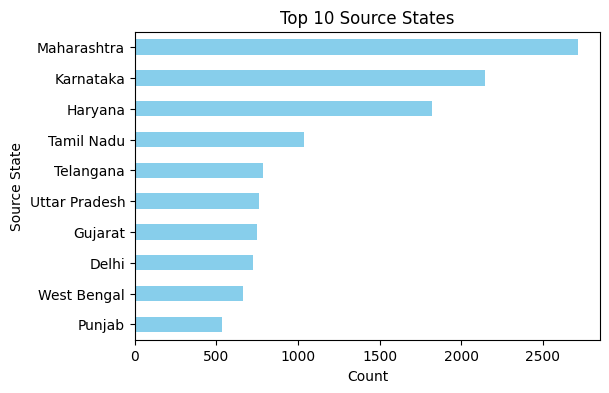

In [33]:
trip_df['source_state'].value_counts(ascending=True).tail(10).plot(
    kind='barh',
    figsize=(6, 4),
    title='Top 10 Source States',
    ylabel='Source State',
    xlabel='Count',
    color='skyblue'
)
plt.show()

> Top 10 destination states:

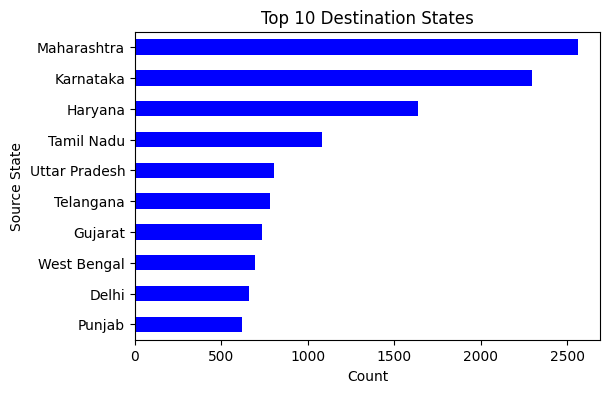

In [34]:
trip_df['destination_state'].value_counts(ascending=True).tail(10).plot(
    kind='barh',
    figsize=(6, 4),
    title='Top 10 Destination States',
    ylabel='Source State',
    xlabel='Count',
    color='blue'
)
plt.show()

> Top 10 State-wise Corridors:

In [35]:
trip_df.groupby(['source_state', 'destination_state'])[
    'trip_uuid'].count().sort_values(ascending=False).head(10)

source_state    destination_state
Maharashtra     Maharashtra          2453
Karnataka       Karnataka            2057
Tamil Nadu      Tamil Nadu           1021
Haryana         Haryana               945
Telangana       Telangana             689
Gujarat         Gujarat               629
West Bengal     West Bengal           615
Uttar Pradesh   Uttar Pradesh         592
Rajasthan       Rajasthan             453
Andhra Pradesh  Andhra Pradesh        414
Name: trip_uuid, dtype: int64

> Top 10 Source Cities:

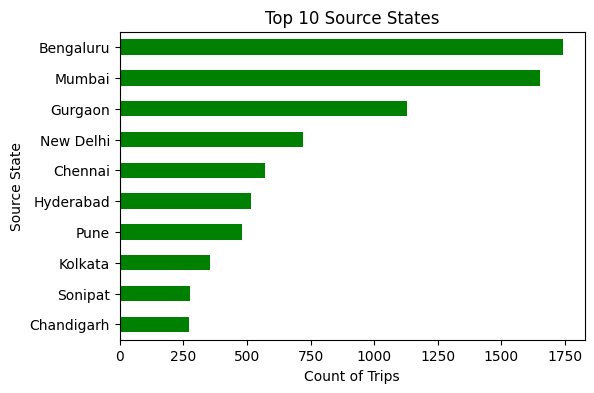

In [ ]:
trip_df['source_city'].value_counts(ascending=True).tail(10).plot(
    kind='barh',
    figsize=(6, 4),
    title='Top 10 Source Cities',
    ylabel='City',
    xlabel='Count of Trips',
    color='green'
)
plt.show()

> Top 10 Destination Cities

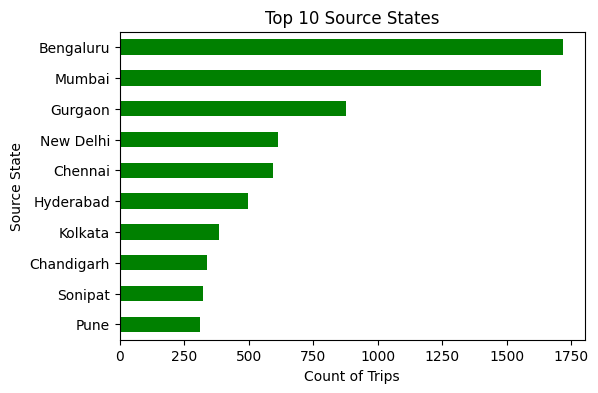

In [ ]:
trip_df['destination_city'].value_counts(ascending=True).tail(10).plot(
    kind='barh',
    figsize=(6, 4),
    title='Top 10 Destination States',
    ylabel='City',
    xlabel='Count of Trips',
    color='green'
)
plt.show()

> Top 10 City-wise Corridors:

In [38]:
trip_df.groupby(['source_city', 'destination_city'])[
    'trip_uuid'].count().sort_values(ascending=False).head(10)

source_city  destination_city
Bengaluru    Bengaluru           1487
Mumbai       Mumbai              1396
Chennai      Chennai              531
Hyderabad    Hyderabad            355
Kolkata      Kolkata              274
New Delhi    Gurgaon              261
Gurgaon      New Delhi            252
             Gurgaon              175
New Delhi    New Delhi            174
Chandigarh   Chandigarh           142
Name: trip_uuid, dtype: int64

> Top 10 Source Places:

In [39]:
trip_df.groupby(['source_city', 'source_place'])[
    'trip_uuid'].count().sort_values(ascending=False).head(10)

source_city  source_place
Gurgaon      Bilaspur        1074
Mumbai       Mankoli          697
Bengaluru    Nelmngla         625
             Bomsndra         457
Pune         Tathawde         396
Mumbai       Mumbai Hub       300
Bengaluru    Kgairprt         295
Hyderabad    Shamshbd         278
Kolkata      Dankuni          245
Chennai      Poonamallee      239
Name: trip_uuid, dtype: int64

> Top 10 Destination Places

In [40]:
trip_df.groupby(['destination_city', 'destination_place'])[
    'trip_uuid'].count().sort_values(ascending=False).head(10)

destination_city  destination_place
Gurgaon           Bilaspur             864
Bengaluru         Nelmngla             548
Mumbai            Mankoli              434
Bengaluru         Bomsndra             346
Hyderabad         Shamshbd             339
Sonipat           Kundli               320
Chandigarh        Mehmdpur             274
Bengaluru         Kgairprt             272
Pune              Tathawde             258
Kolkata           Dankuni              235
Name: trip_uuid, dtype: int64

> Top 10 Busiest corridors in terms of no of trips from Source(City,Place) to Destination(City,Place):

In [41]:
trip_df.groupby(['source_city', 'source_place', 'destination_city', 'destination_place'])[
    'trip_uuid'].count().sort_values(ascending=False).head(10).reset_index()

,source_city,source_place,destination_city,destination_place,trip_uuid
0,Bengaluru,Nelmngla,Bengaluru,Kgairprt,151
1,Gurgaon,Bilaspur,Gurgaon,Bilaspur,123
2,Bengaluru,Bomsndra,Bengaluru,Kgairprt,121
3,Bengaluru,Kgairprt,Bengaluru,Nelmngla,108
4,Mumbai,Mankoli,Mumbai,Mumbai Hub,105
5,Mumbai,Chndivli,Mumbai,Mankoli,99
6,Bengaluru,Nelmngla,Bengaluru,Bomsndra,97
7,Muzaffrpur,Bbganj,Muzaffrpur,Bbganj,96
8,Gurgaon,Bilaspur,Sonipat,Kundli,92
9,Bengaluru,Kgairprt,Bengaluru,Bomsndra,86


> Top states with maximum number of trips to other states:

In [42]:
x = trip_df[trip_df['source_state'] != trip_df['destination_state']].groupby(['source_state', 'destination_state'])[
    'trip_uuid'].count().sort_values(ascending=False).reset_index()
x.head(10)

,source_state,destination_state,trip_uuid
0,Delhi,Haryana,387
1,Haryana,Delhi,312
2,Haryana,Uttar Pradesh,121
3,Haryana,Punjab,97
4,Delhi,Uttar Pradesh,92
5,Haryana,Rajasthan,83
6,Uttar Pradesh,Delhi,76
7,Chandigarh,Punjab,74
8,Uttar Pradesh,Haryana,60
9,Maharashtra,Karnataka,54


Further Aggregating by source_state:

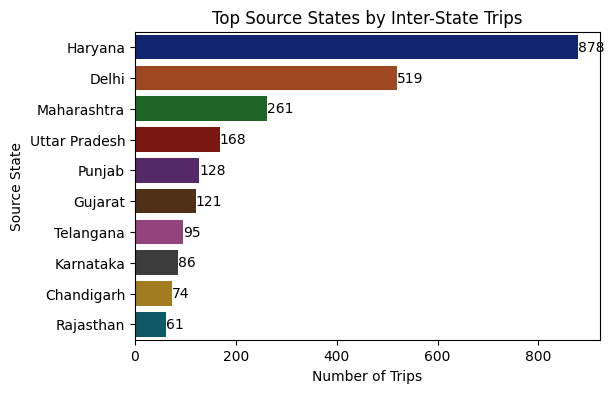

In [43]:
plt.figure(figsize=(6, 4))
plt.title('Top Source States by Inter-State Trips')
plt.xlabel('Number of Trips')
plt.ylabel('Source State')
yy = x.groupby('source_state')['trip_uuid'].sum(
).sort_values(ascending=False).head(10).to_frame()
ord = yy['trip_uuid'].sort_values(ascending=False).index.tolist()
ax = sns.barplot(data=yy, x='trip_uuid', y=yy['trip_uuid'].index.astype(
    str), order=ord, orient='y', palette='dark', hue=ord)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

We see that the most inter-state trips were booked in Haryana. Followed by Delhi, Maharashtra and UP.

In [191]:
x = (
    trip_df[(trip_df['source_city'] != trip_df['destination_city']) &
            (trip_df['source_state'] != trip_df['destination_state'])]
    .groupby(['source_city', 'destination_city'])['trip_uuid'].count()
    .sort_values(ascending=False).reset_index()
)
x.head(10)

,source_city,destination_city,trip_uuid
0,New Delhi,Gurgaon,261
1,Gurgaon,New Delhi,252
2,New Delhi,Sonipat,80
3,Gurgaon,Jaipur,50
4,Gurgaon,Noida,48
5,Gurgaon,Bengaluru,47
6,New Delhi,Faridabad,46
7,Gurgaon,Chandigarh,41
8,Noida,New Delhi,40
9,Faridabad,New Delhi,37


We see that New Delhi - Guargaon tops the list of inter-state, intercity corridors.

> Top states with maximum number of trips to other states:

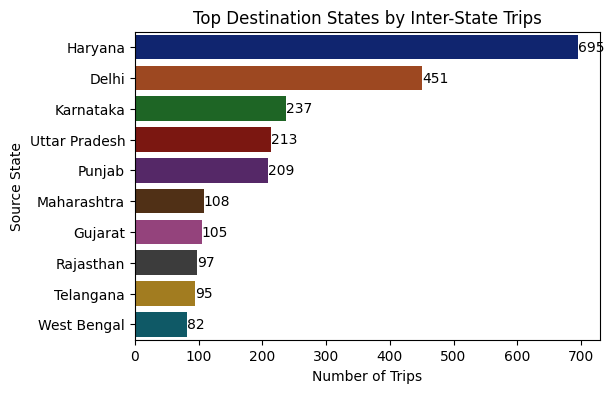

In [44]:
x = trip_df[trip_df['source_state'] != trip_df['destination_state']].groupby(['destination_state', 'source_state'])[
    'trip_uuid'].count().sort_values(ascending=False).reset_index()
plt.figure(figsize=(6, 4))
plt.title('Top Destination States by Inter-State Trips')
plt.xlabel('Number of Trips')
plt.ylabel('Source State')
yy = x.groupby('destination_state')['trip_uuid'].sum(
).sort_values(ascending=False).head(10).to_frame()
ord = yy['trip_uuid'].sort_values(ascending=False).index.tolist()
ax = sns.barplot(data=yy, x='trip_uuid', y=yy['trip_uuid'].index.astype(
    str), order=ord, orient='y', palette='dark', hue=ord)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

We see that Haryana tops this list by a considerable margin. It is followed by Delhi, Karnataka, UP and Punjab.

> Top 10 source cities that had trips ending in other cities within the same state:

In [45]:
x = (
    trip_df[(trip_df['source_city'] != trip_df['destination_city']) &
            (trip_df['source_state'] == trip_df['destination_state'])]
    .groupby(['source_city', 'destination_city'])['trip_uuid'].count()
    .sort_values(ascending=False).reset_index()
)
x.head(10)

,source_city,destination_city,trip_uuid
0,Bengaluru,Hbr Layout Pc,96
1,Gurgaon,Sonipat,92
2,Gurgaon,Faridabad,88
3,Sonipat,Gurgaon,86
4,Pune,Mumbai,74
5,Mumbai,Pune,70
6,Lowerparel,Mumbai,65
7,Faridabad,Gurgaon,63
8,Gurgaon,Ggn,59
9,Ahmedabad,Amd,58


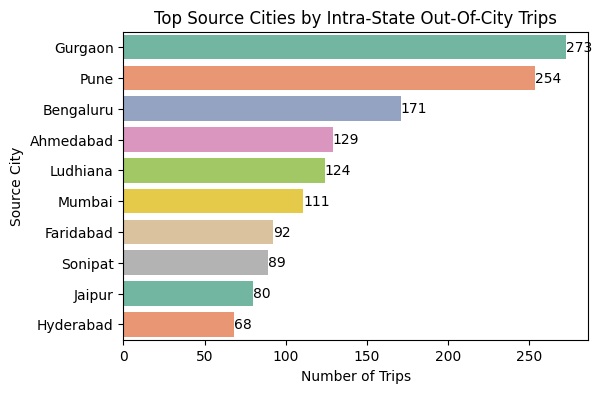

In [46]:
plt.figure(figsize=(6, 4))
plt.title('Top Source Cities by Intra-State Out-Of-City Trips')
plt.xlabel('Number of Trips')
plt.ylabel('Source City')
yy = x.groupby('source_city')['trip_uuid'].sum().sort_values(
    ascending=False).head(10).to_frame()
ord = yy['trip_uuid'].sort_values(ascending=False).index.tolist()
ax = sns.barplot(data=yy, x='trip_uuid', y=yy['trip_uuid'].index.astype(
    str), order=ord, orient='y', palette='Set2', hue=ord)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

We see that Gurgaon, Pune and Bengaluru are the top 3 source cities from where most trips to other intra-state trips were booked.

> Top 10 Cities that had trips within the same city (intra-city trips):

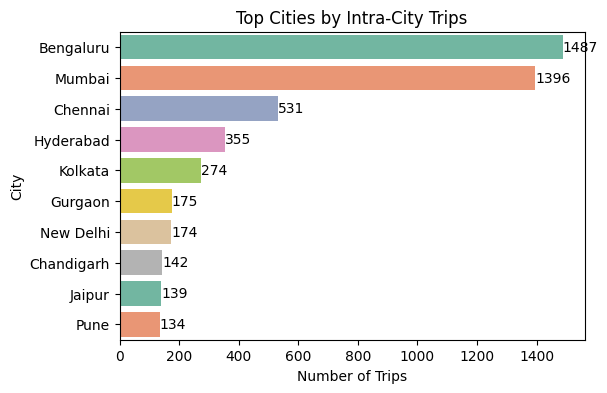

In [47]:
x = (
    trip_df[trip_df['source_city'] == trip_df['destination_city']]
    .groupby(['source_city'])['trip_uuid'].count()
    .sort_values(ascending=False).to_frame()
)
plt.figure(figsize=(6, 4))
plt.title('Top Cities by Intra-City Trips')
plt.xlabel('Number of Trips')
plt.ylabel('City')
yy = x.head(10)
ord = yy['trip_uuid'].sort_values(ascending=False).index.tolist()
ax = sns.barplot(data=yy, x='trip_uuid', y=yy['trip_uuid'].index.astype(
    str), order=ord, orient='y', palette='Set2', hue=ord, legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

We see that the most intra-city trips happen in the metro cities. The list is dominated by Bangalore and Mumbai as the top 2. They are followed by Chennai, Hyderabad and Kolkata.

We can find the average of various numerical factors at each state level (ordered by the total number of trips originating there):

In [48]:
agg_dict = {'trip_uuid': 'count', 'start_scan_to_end_scan': 'mean', 'actual_distance_to_destination': 'mean', 'actual_time': 'mean', 'od_time_diff_hour': 'mean',
            'osrm_time': 'mean', 'osrm_distance': 'mean', 'segment_actual_time_sum': 'mean', 'segment_osrm_distance_sum': 'mean', 'segment_osrm_time_sum': 'mean'}
trip_df.groupby('source_state').agg(agg_dict).sort_values(
    by='trip_uuid', ascending=False).head(10)

,trip_uuid,start_scan_to_end_scan,actual_distance_to_destination,actual_time,od_time_diff_hour,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
source_state,,,,,,,,,,
Maharashtra,2714,440.095063,137.744897,296.011054,440.775217,127.662491,168.167217,293.305822,179.687624,139.992999
Karnataka,2143,360.986001,101.066747,216.629491,361.738959,107.767615,125.059287,214.237051,135.265242,117.363042
Haryana,1823,836.546352,343.544848,643.689523,837.247152,319.009325,418.993169,636.997257,468.448669,371.072957
Tamil Nadu,1039,280.906641,73.273902,158.486044,281.887072,82.804620,91.348242,156.591915,96.687489,89.364774
Telangana,784,522.600765,148.188139,303.660714,523.612746,143.080357,183.967344,300.890306,196.529853,155.960459
Uttar Pradesh,760,621.328947,152.847693,399.360526,622.446483,152.940789,191.210069,396.401316,230.232812,188.730263
Gujarat,750,485.690667,175.422762,331.470667,486.605760,165.721333,212.373545,328.358667,224.539103,175.988000
Delhi,725,355.757241,98.259261,225.812414,356.322891,99.091034,119.858579,223.544828,130.544514,108.566897
West Bengal,665,623.929323,167.130800,465.124812,624.958914,166.939850,214.604536,462.018045,247.189224,191.580451


We visualize outliers in the numerical columns using box plots:

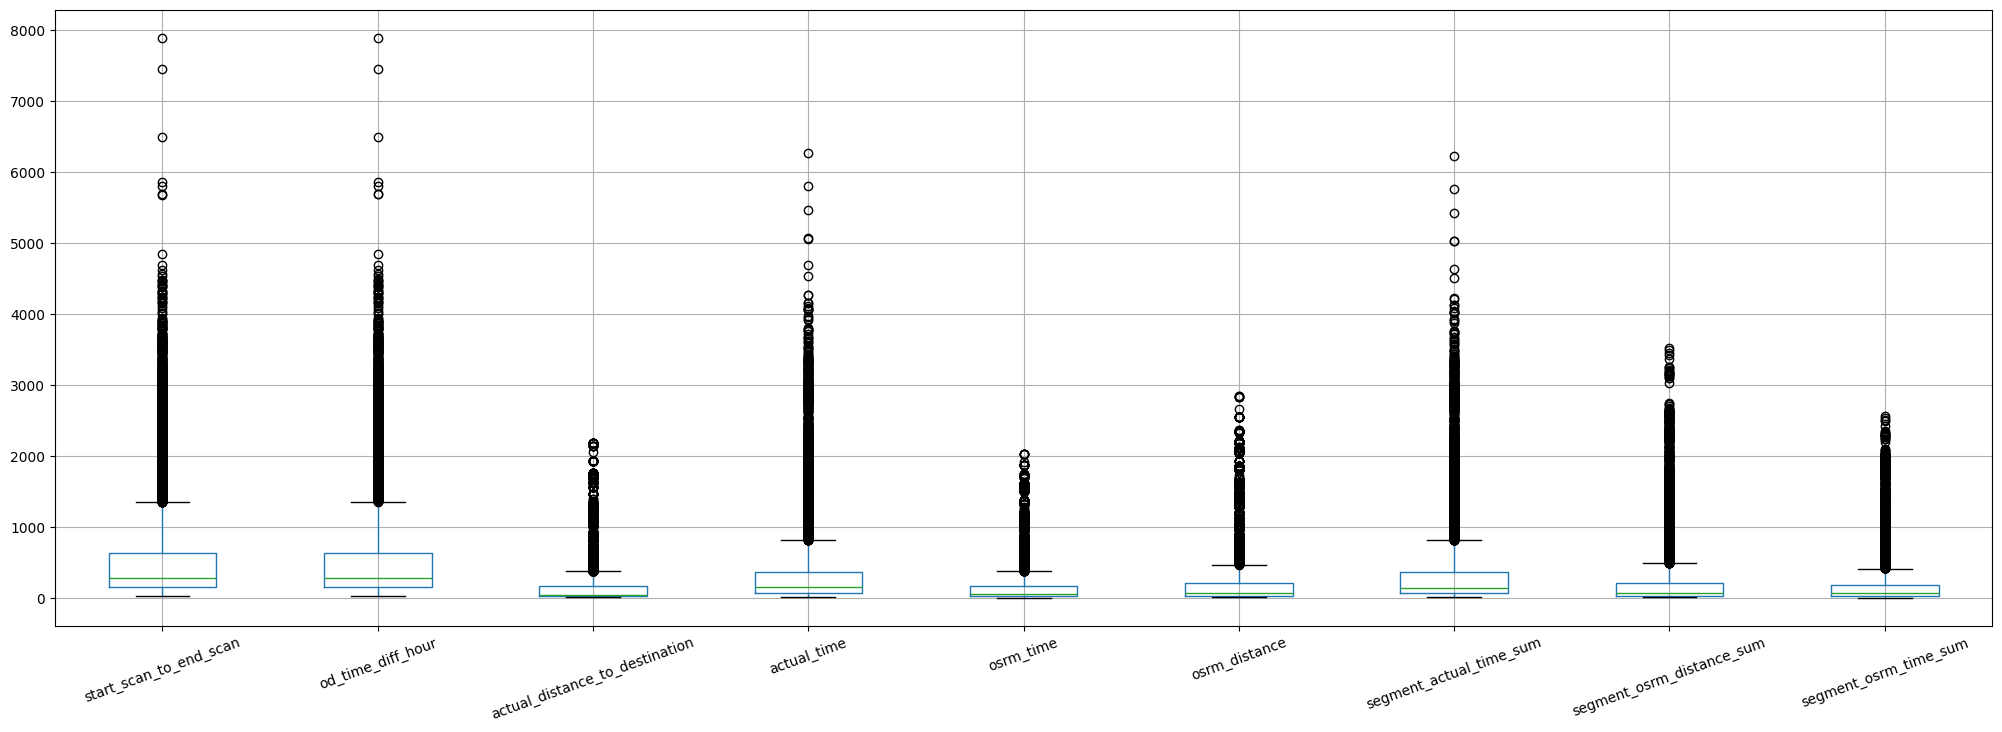

In [49]:
num_cols = trip_df.select_dtypes(include='float').columns
trip_df[num_cols].boxplot(rot=20, figsize=(25, 8))
plt.show()

Outliers are just extreme values in this particular scenario. It is not entirely productive to remove them as these extreme values do have information pertaining to long distance trips. However, as instructed, we use the IQR method to handle the outliers.

In [50]:
Q1 = trip_df[num_cols].quantile(0.25)
Q3 = trip_df[num_cols].quantile(0.75)

IQR = Q3 - Q1

trip = trip_df[~((trip_df[num_cols] < (Q1 - 1.5 * IQR)) | (trip_df[num_cols]
                 > (Q3 + 1.5 * IQR))).any(axis=1)].reset_index(drop=True)
trip

,data,trip_creation_time,route_type,trip_uuid,source_name,destination_name,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,...,day,weekday,week,month,source_state,destination_state,source_city,source_place,destination_city,destination_place
0,training,2018-09-12 00:00:22.886430,Carting,trip-153671042288605164,doddablpur_chikadpp_d (karnataka),doddablpur_chikadpp_d (karnataka),180.0,181.611874,73.186911,143.0,...,12,2,37,9,Karnataka,Karnataka,Doddablpur,Chikadpp,Doddablpur,Chikadpp
1,training,2018-09-12 00:01:00.113710,Carting,trip-153671046011330457,mumbai hub (maharashtra),mumbai_mirard_ip (maharashtra),100.0,100.494935,17.175274,59.0,...,12,2,37,9,Maharashtra,Maharashtra,Mumbai,Mumbai Hub,Mumbai,Mirard
2,training,2018-09-12 00:02:09.740725,FTL,trip-153671052974046625,bellary_dc (karnataka),sandur_wrdn1dpp_d (karnataka),717.0,718.349042,127.448500,341.0,...,12,2,37,9,Karnataka,Karnataka,Bellary,Dc,Sandur,Wrdn1Dpp
3,training,2018-09-12 00:02:34.161600,Carting,trip-153671055416136166,chennai_poonamallee (tamil nadu),chennai_poonamallee (tamil nadu),189.0,190.487849,24.597048,61.0,...,12,2,37,9,Tamil Nadu,Tamil Nadu,Chennai,Poonamallee,Chennai,Poonamallee
4,training,2018-09-12 00:04:22.011653,Carting,trip-153671066201138152,chennai_chrompet_dpc (tamil nadu),chennai_vandalur_dc (tamil nadu),98.0,98.005634,9.100510,24.0,...,12,2,37,9,Tamil Nadu,Tamil Nadu,Chennai,Chrompet,Chennai,Vandalur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12718,test,2018-10-03 23:55:56.258533,Carting,trip-153861095625827784,chandigarh_mehmdpur_h (punjab),chandigarh_mehmdpur_h (punjab),257.0,258.028928,57.762332,83.0,...,3,2,40,10,Punjab,Punjab,Chandigarh,Mehmdpur,Chandigarh,Mehmdpur
12719,test,2018-10-03 23:57:23.863155,Carting,trip-153861104386292051,fbd_balabhgarh_dpc (haryana),faridabad_blbgarh_dc (haryana),60.0,60.590521,15.513784,21.0,...,3,2,40,10,Haryana,Haryana,Faridabad,Balabhgarh,Faridabad,Blbgarh
12720,test,2018-10-03 23:57:44.429324,Carting,trip-153861106442901555,kanpur_govndngr_dc (uttar pradesh),kanpur_govndngr_dc (uttar pradesh),421.0,422.119867,38.684839,282.0,...,3,2,40,10,Uttar Pradesh,Uttar Pradesh,Kanpur,Govndngr,Kanpur,Govndngr
12721,test,2018-10-03 23:59:14.390954,Carting,trip-153861115439069069,tirunelveli_vdkkusrt_i (tamil nadu),tirchchndr_shnmgprm_d (tamil nadu),347.0,348.512862,134.723836,264.0,...,3,2,40,10,Tamil Nadu,Tamil Nadu,Tirunelveli,Vdkkusrt,Tirchchndr,Shnmgprm


In [51]:
trip.shape

(12723, 26)

Visualizing the box plots again:

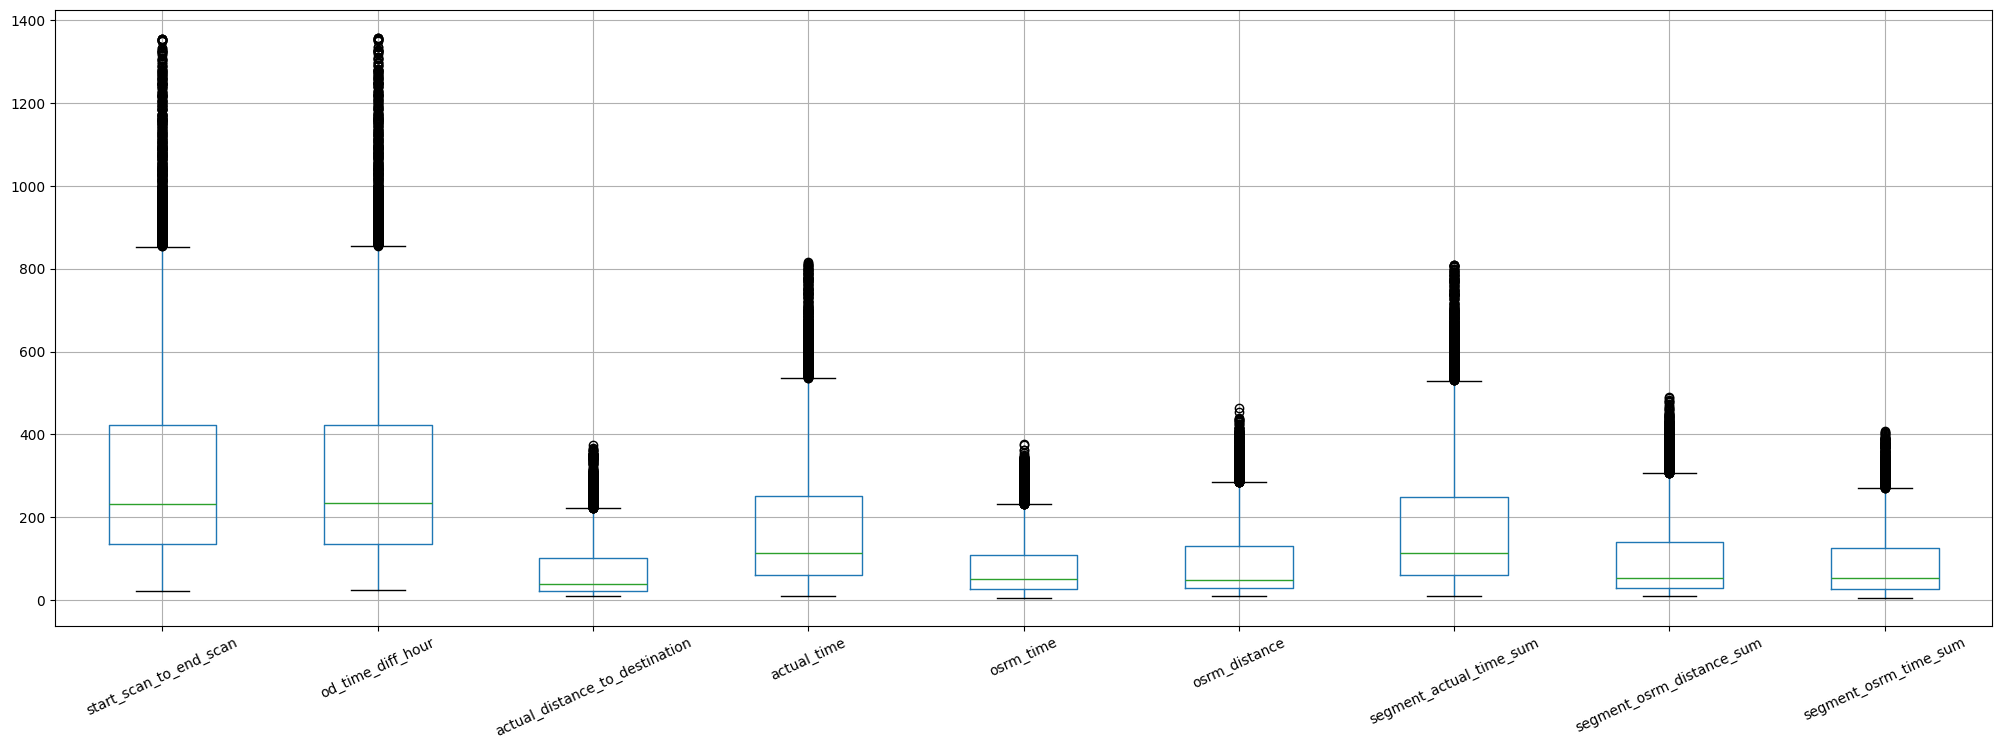

In [52]:
trip[num_cols].boxplot(rot=25, figsize=(25, 8))
plt.show()

>Thus, after handling the outliers using IQR method, we are left with 12723 trips in total. We can use these trips for further analysis.

---

In [53]:
# checkpoint: export the cleaned data to a CSV file
trip.to_csv('delhivery_cleaned.csv', index=False)
df = trip.copy()

---

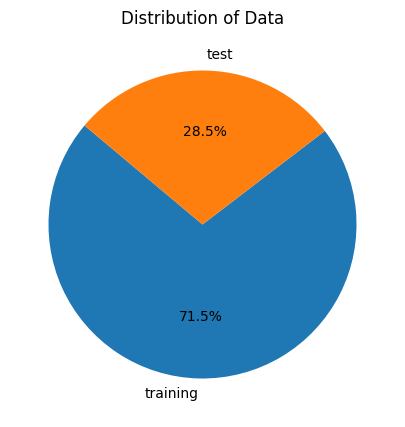

In [54]:
df['data'].value_counts().plot(kind='pie', figsize=(
    10, 5), autopct='%1.1f%%', startangle=140)
plt.ylabel('')
plt.title('Distribution of Data')
plt.show()

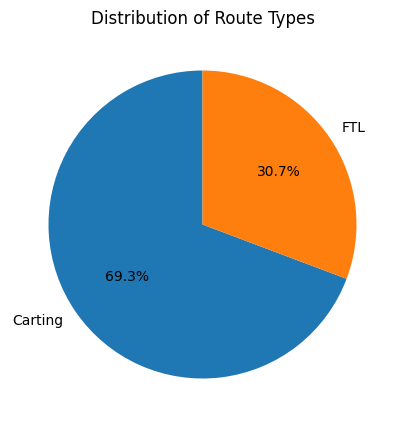

In [55]:
df['route_type'].value_counts().plot(kind='pie', figsize=(
    10, 5), autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Distribution of Route Types')
plt.show()

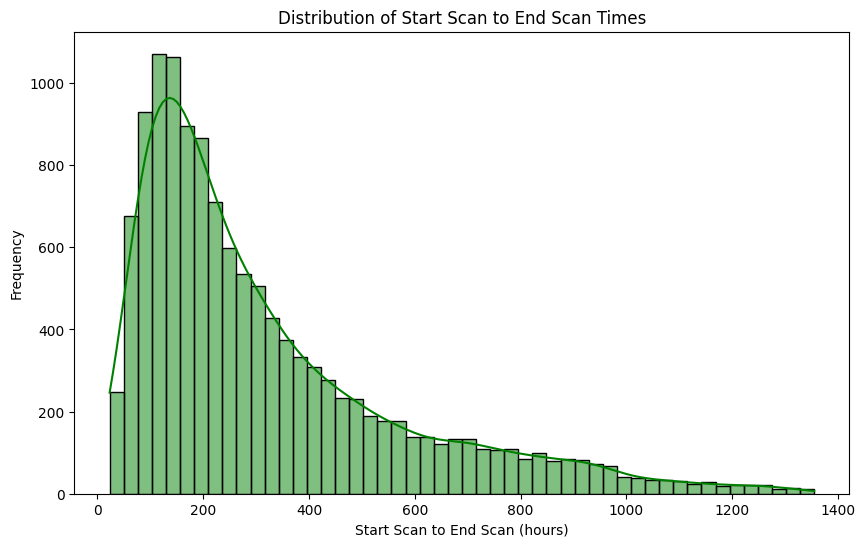

In [56]:
# distribution of start_scan_to_end_scan
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='start_scan_to_end_scan', kde=True, bins=50, color='g')
plt.title('Distribution of Start Scan to End Scan Times')
plt.xlabel('Start Scan to End Scan (hours)')
plt.ylabel('Frequency')
plt.show()

We see that we have a right tailed distribution.

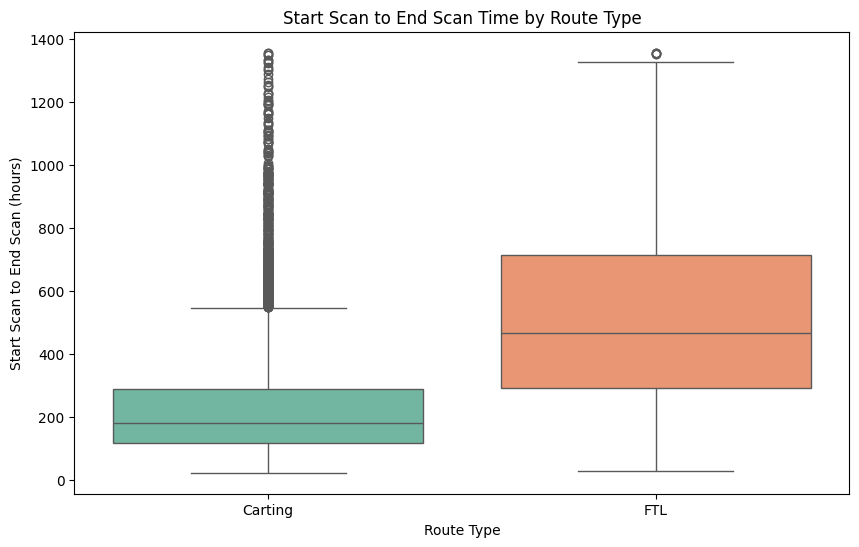

In [57]:
# Box plots of start_scan_to_end_scan across different route_type categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='route_type', y='start_scan_to_end_scan',
            data=df, hue='route_type', palette='Set2')
plt.title('Start Scan to End Scan Time by Route Type')
plt.xlabel('Route Type')
plt.ylabel('Start Scan to End Scan (hours)')
plt.show()

We see that the distributions for start scan to end scan times vary quite a bit based on the route type. FTL has almost no outliers whereas carting has a lot of extreme values. This should be further looked into from a logistical optimization point of view.

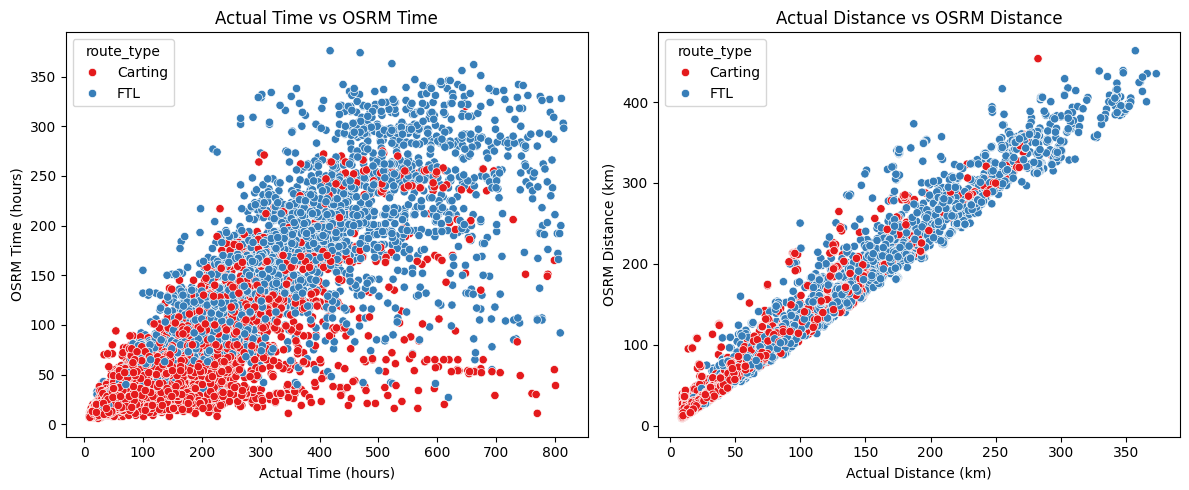

In [58]:
# Scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='actual_time', y='osrm_time', data=df,
                hue='route_type', palette='Set1')
plt.title('Actual Time vs OSRM Time')
plt.xlabel('Actual Time (hours)')
plt.ylabel('OSRM Time (hours)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='actual_distance_to_destination',
                y='osrm_distance', data=df, hue='route_type', palette='Set1')
plt.title('Actual Distance vs OSRM Distance')
plt.xlabel('Actual Distance (km)')
plt.ylabel('OSRM Distance (km)')

plt.tight_layout()
plt.show()

There seems to be a high correlation between the actual distance and OSRM distance whereas the plot of actual time vs OSRM time suggests that the correlation is much lesser in comparison. This suggests that the OSRM model is not accurate enough and/or that the actual time needs to be further optimized to be closer to the OSRM time.

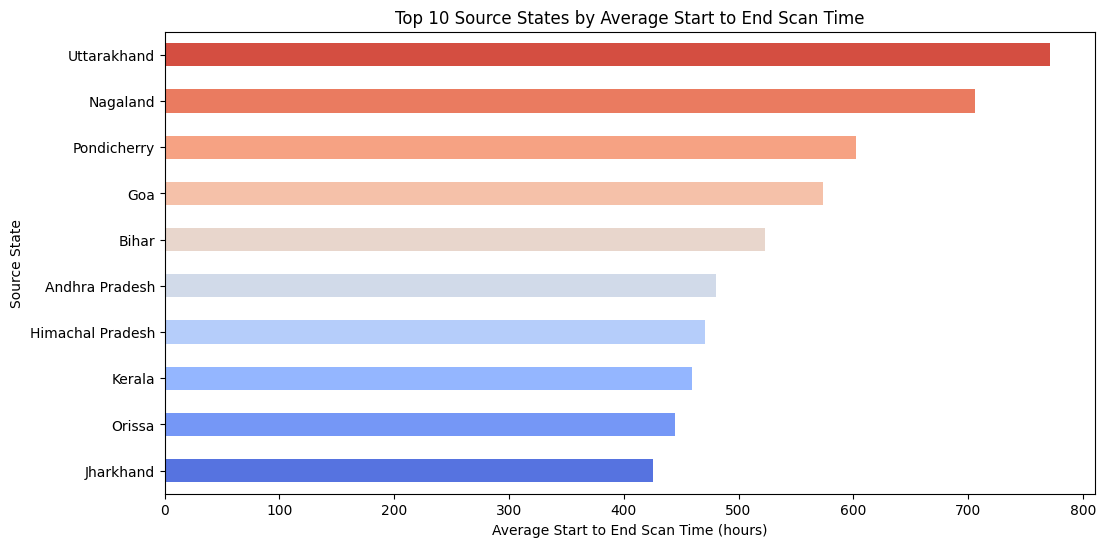

In [59]:
# Average start_scan_to_end_scan for Top 10 Source States
plt.figure(figsize=(12, 6))
avg_scan_by_source_state = df.groupby('source_state')[
    'start_scan_to_end_scan'].mean().nlargest(10).sort_values(ascending=True)
avg_scan_by_source_state.plot(
    kind='barh', color=sns.color_palette('coolwarm', 10))
plt.title('Top 10 Source States by Average Start to End Scan Time')
plt.xlabel('Average Start to End Scan Time (hours)')
plt.ylabel('Source State')
plt.show()

We see that Uttarakhan, Nagaland and Pondicherry have the highest mean start to end scan times as Source States from where trips are being booked.

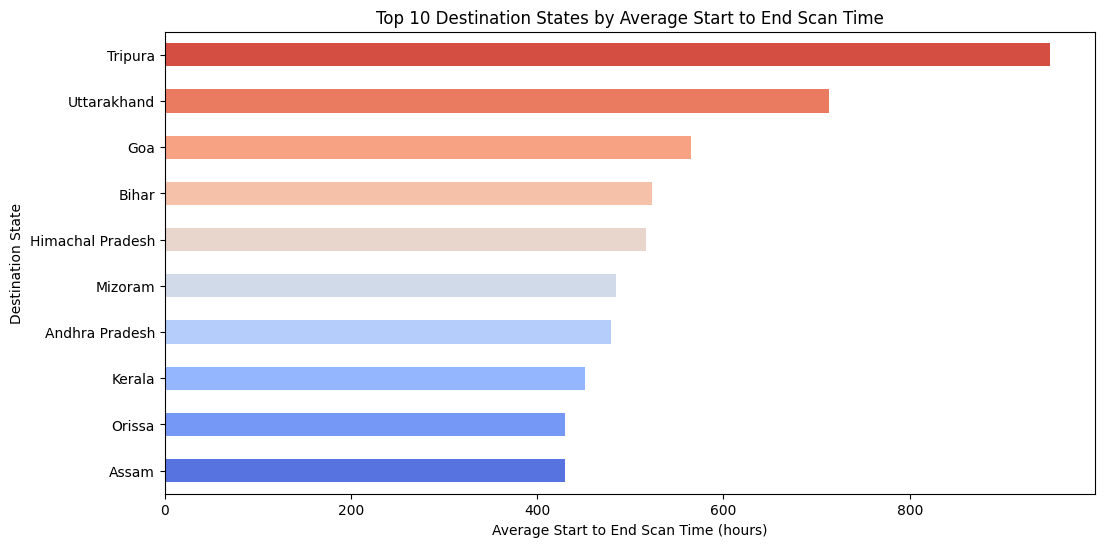

In [60]:
# Average start_scan_to_end_scan for Top 10 Destination States
plt.figure(figsize=(12, 6))
avg_scan_by_destination_state = df.groupby('destination_state')[
    'start_scan_to_end_scan'].mean().nlargest(10).sort_values(ascending=True)
avg_scan_by_destination_state.plot(
    kind='barh', color=sns.color_palette('coolwarm', 10))
plt.title('Top 10 Destination States by Average Start to End Scan Time')
plt.xlabel('Average Start to End Scan Time (hours)')
plt.ylabel('Destination State')
plt.show()

We see that Tripura, Uttarakhand and Goa have the highest mean start to end scan times as Destination States where to trips are being booked.

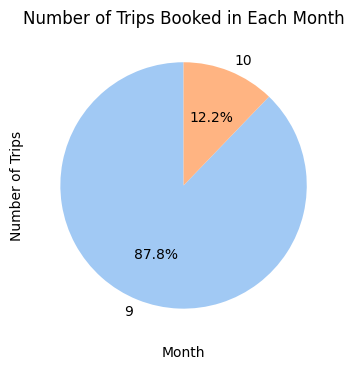

In [61]:
# Visualizing the number of trips booked in each month

plt.figure(figsize=(4, 4))
df['month'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Number of Trips Booked in Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

We see that almost all of our data is from trips in September (9th month) and only 12% comes from October dates.

Visualizing Trips created per hour of the day:

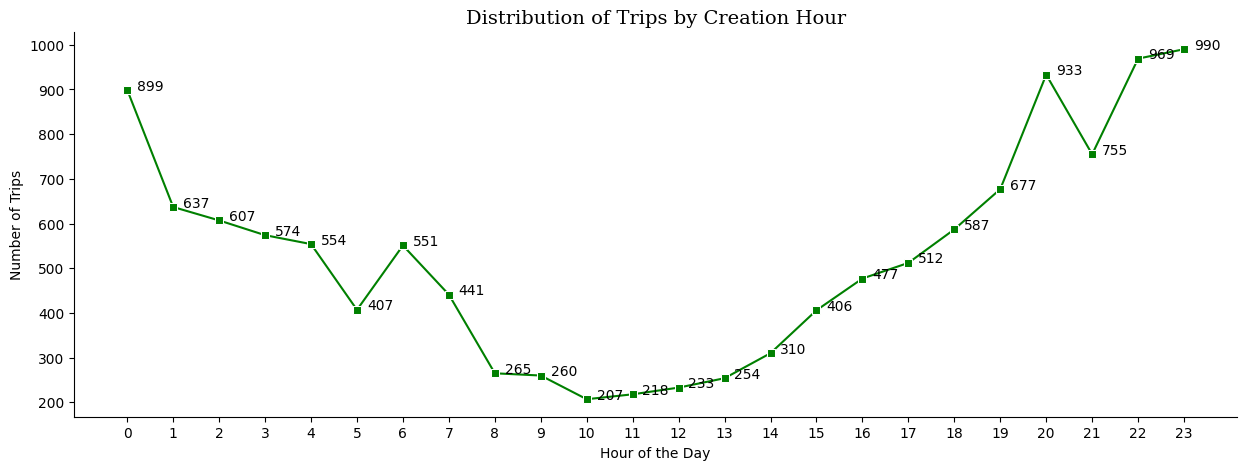

In [62]:
by_hour = df.groupby(by='hour')['trip_uuid'].count().reset_index()

plt.figure(figsize=(15, 5))
sns.lineplot(data=by_hour, x='hour', y='trip_uuid', marker='s', color='g')
plt.xticks(np.arange(0, 24))

for i, count in enumerate(by_hour['trip_uuid']):
    plt.text(by_hour['hour'][i]+0.5, count, count, ha='center')

plt.title('Distribution of Trips by Creation Hour',
          fontsize=14, fontfamily='serif')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
sns.despine()
plt.show()

We see that there is a lull in trip creation from 8am to 2pm. This could be a reflection of office hours. Interestingly the peak is at 11pm, this could be because of actual processing at the warehouses happening late.

Visualizing trips by day of the month:

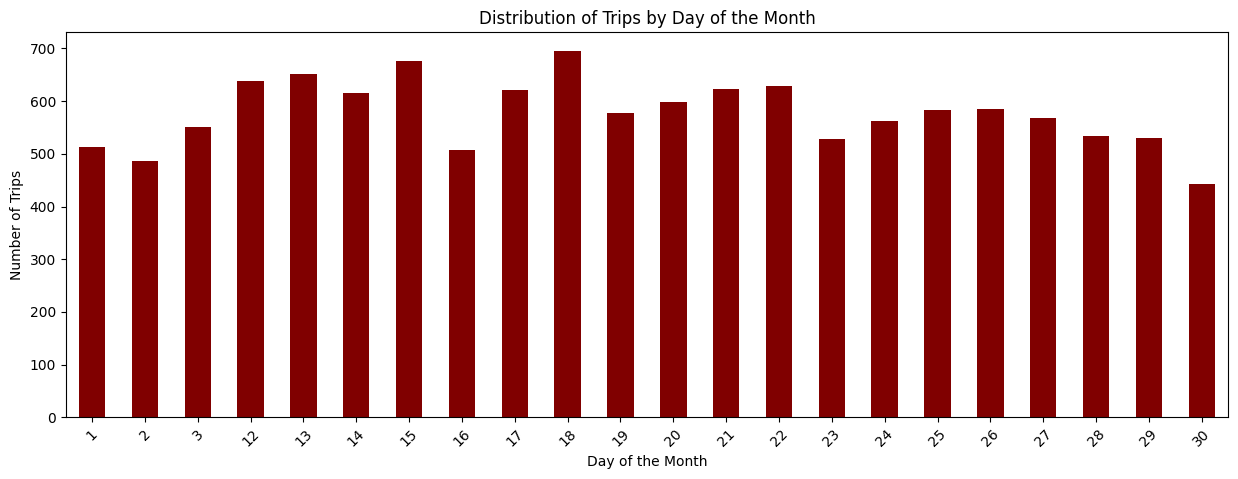

In [63]:
df['day'].value_counts().sort_index().plot(
    kind='bar', figsize=(15, 5), color='maroon')
plt.title('Distribution of Trips by Day of the Month')
plt.xlabel('Day of the Month')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

We see that there is no real pattern to the bookings made per each day of the month. However, we see that we have no booking at all from the 4-11 days. Perhaps it was some holiday or some such?

Visualizing no of trips by day of the week:

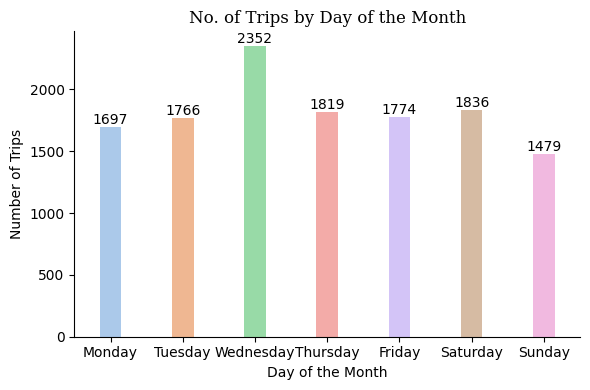

In [64]:
plt.figure(figsize=(6, 4))

weekday_order = ['Monday', 'Tuesday', 'Wednesday',
                 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['weekday'].value_counts().sort_index()
day_counts.index = weekday_order

sns.barplot(x=day_counts.index, y=day_counts.values,
            hue=day_counts.index, palette='pastel', width=0.3)
for i, count in enumerate(day_counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.title('No. of Trips by Day of the Month',
          fontsize=12, fontfamily='serif')
plt.xlabel('Day of the Month')
plt.ylabel('Number of Trips')
plt.tight_layout()
sns.despine()
plt.show()

We see that the most booking are happening on wednesdays. However, overall there is no real pattern except that the least amount of bookings happen on Sundays.

Let us plot a heat map for visualizing the correlation between the numerical fields:

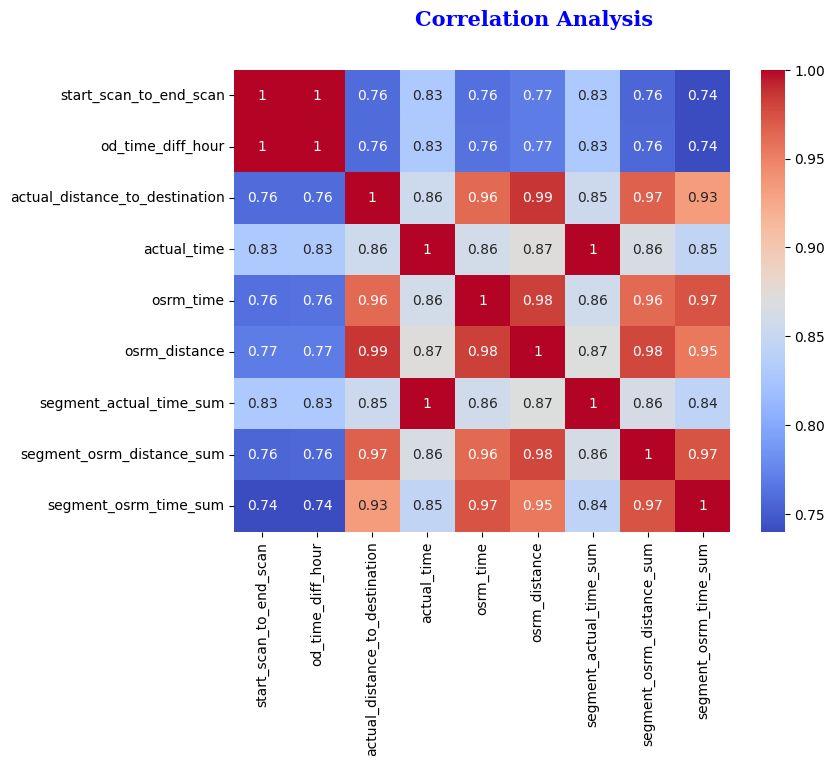

In [65]:
plt.figure(figsize=(8, 6))
plt.suptitle(f'Correlation Analysis', fontfamily='serif',
             fontweight='bold', fontsize=15, color='blue')
sns.heatmap(data=df.loc[:, :'segment_osrm_time_sum'].corr(
    numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

We see that there is a high level of correlation between the main numerical fields (which is to be expected given that they are in fact related such as cumulative sums etc)

Let us inspect the skew of the various numerical fields:

In [66]:
df.loc[:, num_cols].skew(numeric_only=True)

start_scan_to_end_scan            1.461887
od_time_diff_hour                 1.460849
actual_distance_to_destination    1.485214
actual_time                       1.451405
osrm_time                         1.442568
osrm_distance                     1.440438
segment_actual_time_sum           1.458996
segment_osrm_distance_sum         1.426506
segment_osrm_time_sum             1.395665
dtype: float64

> We see that the fields are right skewed ie positively skewed. This means that even though most of the values are concentrated towards the left, there are a lot of extreme values making the distribution right tailed.

Visualizing the skew:

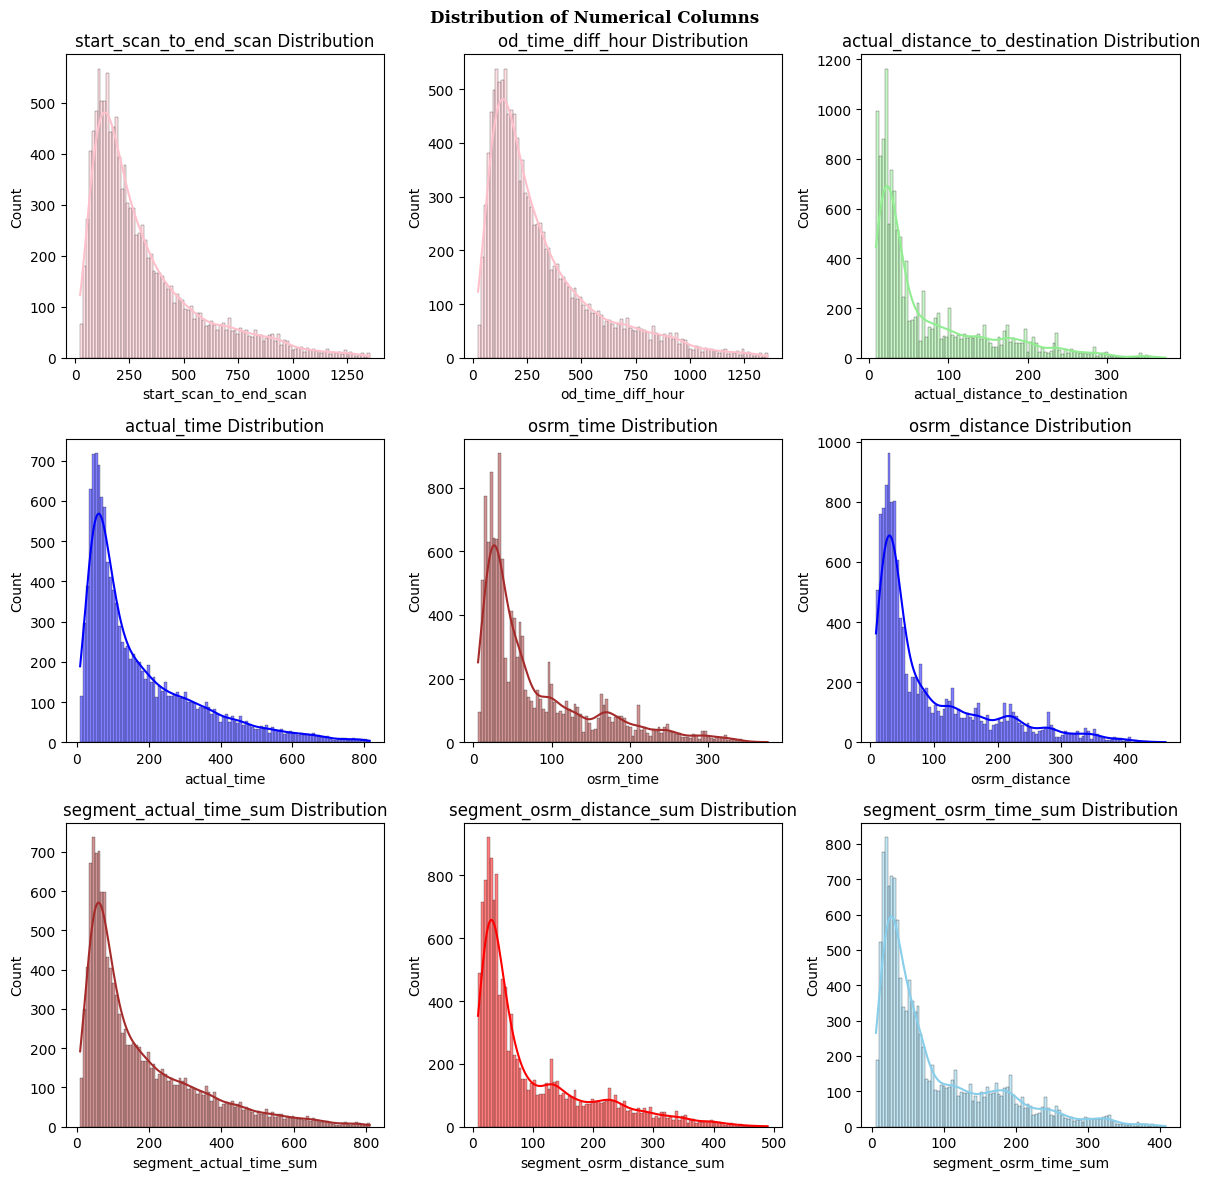

In [67]:
plt.figure(figsize=(12, 12))
plt.suptitle('Distribution of Numerical Columns', fontsize=12, fontfamily='serif', fontweight='bold', color='k')
for i in range(len(num_cols)):
    plt.subplot(3, 3, i + 1)
    clr = np.random.choice(['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink','skyblue', 'lightgreen', 'lightcoral'])
    sns.histplot(trip[num_cols[i]], bins=100, kde=True, color=clr)
    plt.title(f"{num_cols[i]} Distribution")
    plt.plot()
plt.tight_layout()
plt.show()

The skew is very evident from these plots.

---

## Hypothesis Testing

Explained below is the process we will follow to do hypothesis testing between various fields in our dataset:

***STEP-1*** : Set up Null ($H_0$) and Alternate ($H_a$) Hypotheses

***STEP-2*** : Checking for basic assumpitons for the hypothesis

* Testing Homogeneity of Variances using **Lavene's test**
* Testing Normality using **QQ Plot** and/or **Shapiro-Wilk Test**

***STEP-3***: Define Test statistics; Distribution under $H_0$.

* If the assumptions of T-Test are met then we conduct **T-Test** for independent samples. If not, we perform the equivalent non-parametric test i.e., **Mann-Whitney U rank test** for two independent samples.


***STEP-4***: Compute the p-value.

* We choose $\alpha=0.05$.

***STEP-5***: Compare p-value and alpha. 

* Based on p-value, we will accept or reject $H_0$.


  1.   **p-val < alpha** : Reject $H_0$
  2.   **p-val > alpha** : Fail to Reject $H_0$

Defining functions for performing each of these steps:

In [113]:
# function to visualize the distributions of two columns using KDE plots

def kde_visualization(df,cols):
    plt.figure(figsize = (12, 6))
    plt.suptitle(f'Distributions of {cols[0]} vs {cols[1]}', fontsize=15, fontfamily='serif', color='darkblue')
    plt.subplot(1, 2, 1)
    sns.histplot(data=df,x=cols[0], color='blue', kde=True, bins=50)
    plt.subplot(1, 2, 2)
    sns.histplot(data=df,x=cols[1], color='green', kde=True, bins=50)
    plt.tight_layout()
    plt.plot()

In [112]:
# function for QQ plot
def qq_plot(df,col):
    print(f'QQ plot for {col}:')
    stats.probplot(df[col], plot = plt, dist = 'norm')    
    plt.show()

In [ ]:
# function for levene's test

def levene_test(df, cols):
    # from scipy.stats import levene
    stat, p = np.round(stats.levene(df[cols[0]], df[cols[1]]),5)
    print(f'H0: The variances of the two columns {cols[0]} and {cols[1]} are equal')
    print('H1: The variances of the two columns are not equal')
    print(f'Levene\'s test statistic: {stat}, p-value: {p}')
    if p > 0.05:
        print('The variances are equal (fail to reject H0)')
    else:
        print('The variances are not equal (reject H0)')

In [129]:
# function for t-test
def t_test(df, cols):
    # from scipy.stats import ttest_ind
    stat, p = np.round(stats.ttest_ind(df[cols[0]], df[cols[1]]), 5)
    print(f'H0: The means of the two columns {cols[0]} and {cols[1]} are equal')
    print('H1: The means of the two columns are not equal')
    print(f'T-test statistic: {stat}, p-value: {p}')
    if p > 0.05:
        print('The means are equal (fail to reject H0)')
    else:
        print('The means are not equal (reject H0)')

In [130]:
# function for mann-whitney u test

def mann_whitney_u_test(df, cols):
    # from scipy.stats import mannwhitneyu
    stat, p = np.round(stats.mannwhitneyu(df[cols[0]], df[cols[1]]),5)
    print(f'H0: The distributions of the two columns {cols[0]} and {cols[1]} are identical')
    print('H1: The distributions of the two columns are not identical')
    print(f'Mann-Whitney U test statistic: {stat}, p-value: {p}')
    if p > 0.05:
        print('The distributions of {cols[0]} and {cols[1]} are identical (fail to reject H0)')
    else:
        print('The distributions are not identical (reject H0)')

### 1. `start_scan_to_end_scan` vs `od_time_diff_hour`

Setting up hypotheses:

$$H_0 \text{: Means of the two columns are the same.}$$
$$H_0 \text{: Means of the two columns are not the same.}$$



In [172]:
ht_cols=['start_scan_to_end_scan', 'od_time_diff_hour']

In [173]:
df[ht_cols].mean()

start_scan_to_end_scan    320.178731
od_time_diff_hour         321.022701
dtype: float64

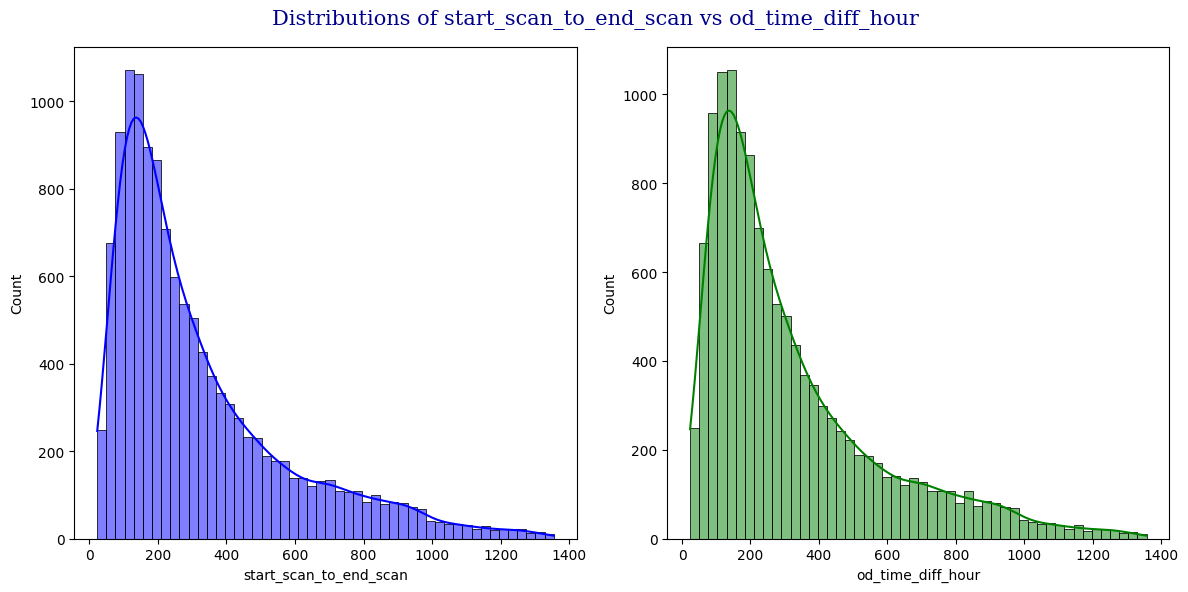

In [132]:
kde_visualization(df,ht_cols)

In [133]:
ht_cols

['start_scan_to_end_scan', 'od_time_diff_hour']

QQ plot for start_scan_to_end_scan:


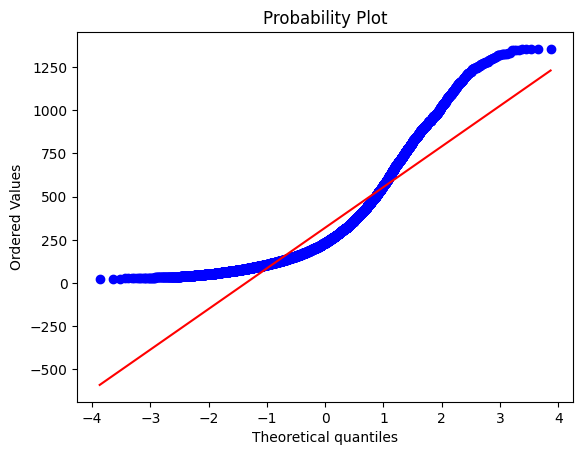

In [134]:
qq_plot(df,ht_cols[0])

QQ plot for od_time_diff_hour:


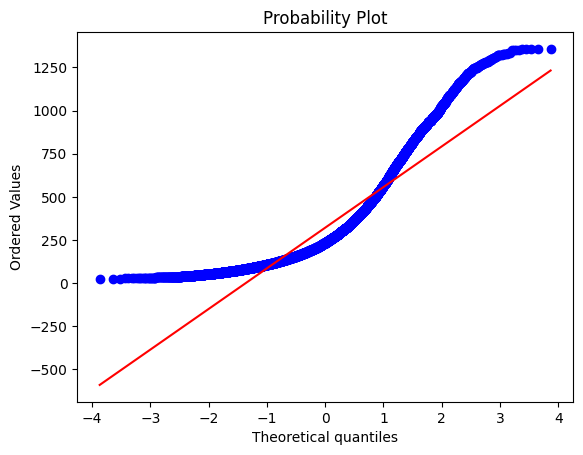

In [135]:
qq_plot(df,ht_cols[1])

In [136]:
levene_test(df, ht_cols)

H0: The variances of the two columns start_scan_to_end_scan and od_time_diff_hour are equal
H1: The variances of the two groups are not equal
Levene's test statistic: 0.01148, p-value: 0.91468
The variances are equal (fail to reject H0)


It is clear that these distributions do not have normality even as the variances are equal. Thus, we perform Mann-Whitney U test instead of T-test.

In [137]:
mann_whitney_u_test(df, ht_cols)

H0: The distributions of the two columns start_scan_to_end_scan and od_time_diff_hour are identical
H1: The distributions of the two columns are not identical
Mann-Whitney U test statistic: 80740343.0, p-value: 0.73666
The distributions of {cols[0]} and {cols[1]} are identical (fail to reject H0)


> Thus, we find that these two columns - `start_scan_to_end_scan` vs `od_time_diff_hour` - are not dissimilar.

### 2. `actual_time` vs `osrm_time`

Setting up hypotheses:

$$H_0 \text{: Means of the two columns are the same.}$$
$$H_0 \text{: Means of the two columns are not the same.}$$



In [174]:
ht_cols=['actual_time', 'osrm_time']

In [175]:
df[ht_cols].mean()

actual_time    177.452723
osrm_time       78.440305
dtype: float64

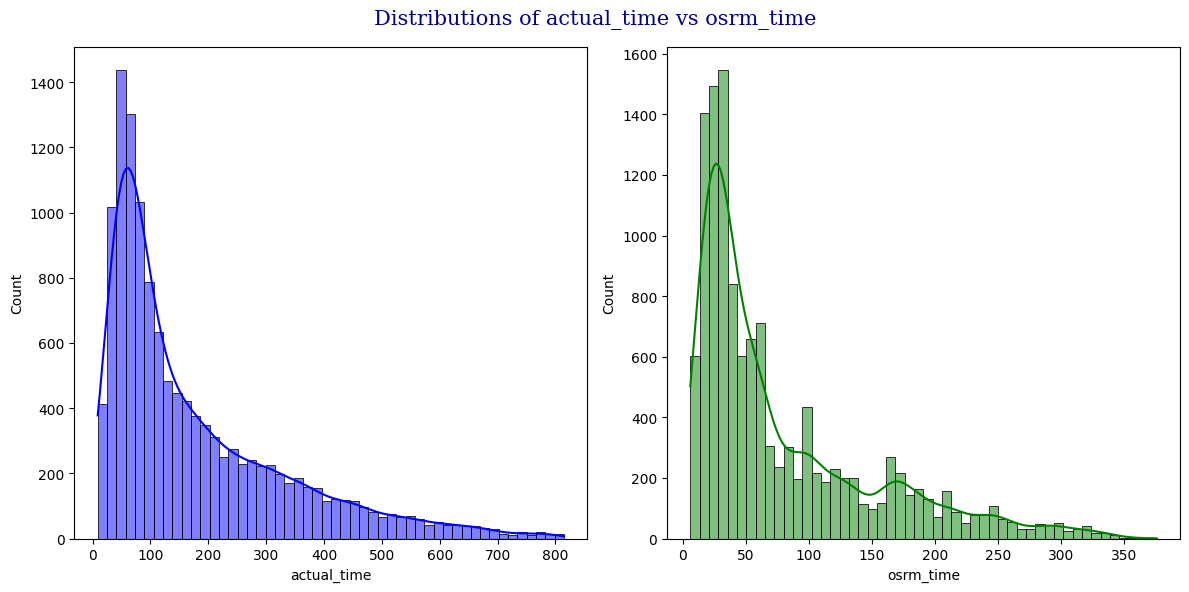

In [139]:
kde_visualization(df,ht_cols)

QQ plot for actual_time:


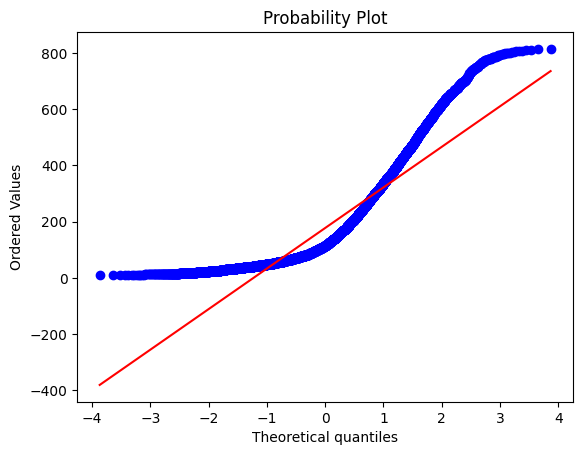

In [140]:
qq_plot(df,ht_cols[0])

QQ plot for osrm_time:


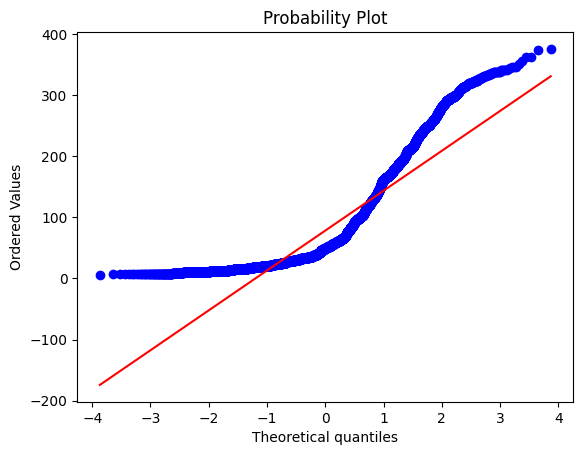

In [141]:
qq_plot(df,ht_cols[1])

In [142]:
levene_test(df, ht_cols)

H0: The variances of the two columns actual_time and osrm_time are equal
H1: The variances of the two groups are not equal
Levene's test statistic: 2622.79812, p-value: 0.0
The variances are not equal (reject H0)


It is clear that these distributions do not have normality and that the variances are unequal. Thus, we perform Mann-Whitney U test instead of T-test.

In [143]:
mann_whitney_u_test(df, ht_cols)

H0: The distributions of the two columns actual_time and osrm_time are identical
H1: The distributions of the two columns are not identical
Mann-Whitney U test statistic: 119494540.0, p-value: 0.0
The distributions are not identical (reject H0)


> Thus, we find that these two columns - `actual_time` vs `osrm_time` - are in fact dissimilar. This means that the time predicted by the OSRM model is not accurate. Or that we need to really understand why it is varying so much in practice. Is it down to logistical inefficiencies within the system or something else needs to be investigated.

### 3. `segment_actual_time_sum` vs `segment_osrm_time_sum`

Setting up hypotheses:

$$H_0 \text{: Means of the two columns are the same.}$$
$$H_0 \text{: Means of the two columns are not the same.}$$



In [176]:
ht_cols=['segment_actual_time_sum', 'segment_osrm_time_sum']

In [177]:
df[ht_cols].mean()

segment_actual_time_sum    175.796274
segment_osrm_time_sum       85.908355
dtype: float64

In [171]:
df[ht_cols].mean()

segment_actual_time_sum    175.796274
segment_osrm_time_sum       85.908355
dtype: float64

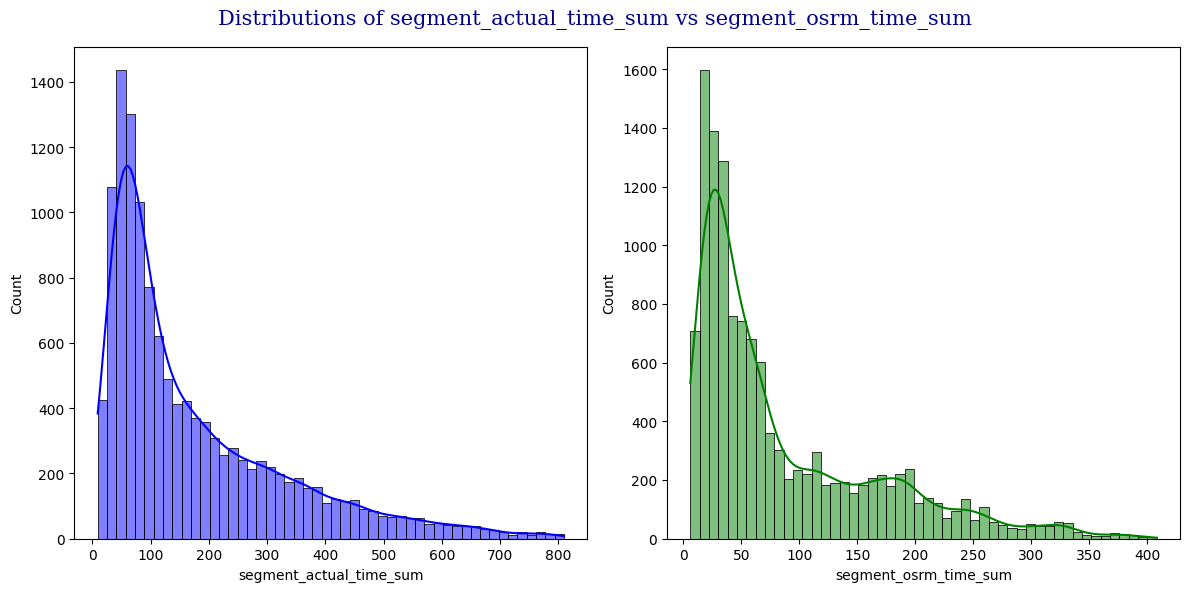

In [145]:
kde_visualization(df,ht_cols)

QQ plot for segment_actual_time_sum:


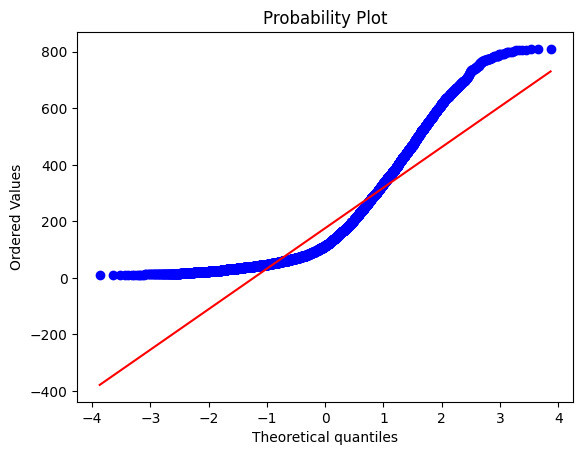

In [147]:
qq_plot(df,ht_cols[0])

QQ plot for segment_osrm_time_sum:


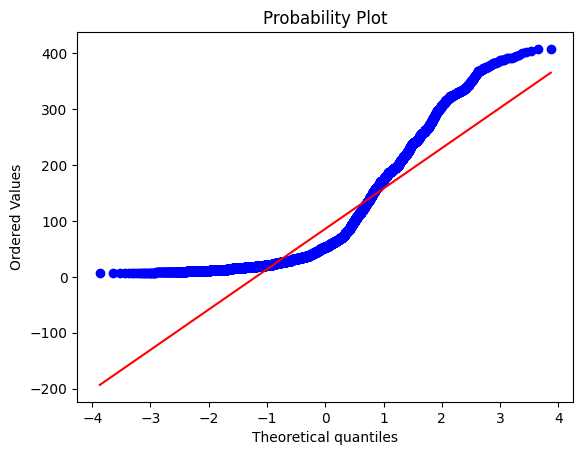

In [148]:
qq_plot(df,ht_cols[1])

In [149]:
levene_test(df, ht_cols)

H0: The variances of the two columns segment_actual_time_sum and segment_osrm_time_sum are equal
H1: The variances of the two groups are not equal
Levene's test statistic: 2043.52023, p-value: 0.0
The variances are not equal (reject H0)


It is clear that these distributions do not have normality even as the variances are equal. Thus, we perform Mann-Whitney U test instead of T-test.

In [150]:
mann_whitney_u_test(df, ht_cols)

H0: The distributions of the two columns segment_actual_time_sum and segment_osrm_time_sum are identical
H1: The distributions of the two columns are not identical
Mann-Whitney U test statistic: 115444276.0, p-value: 0.0
The distributions are not identical (reject H0)


> Thus, we find that these two columns - `segment_actual_time_sum` vs `segment_osrm_time_sum` - are in fact different. Once again, this calls into question how well the OSRM model is working

### 4. `actual_distance_to_destination` vs `osrm_distance`

Setting up hypotheses:

$$H_0 \text{: Means of the two columns are the same.}$$
$$H_0 \text{: Means of the two columns are not the same.}$$



In [178]:
ht_cols=['actual_distance_to_destination', 'osrm_distance']

In [179]:
df[ht_cols].mean()

actual_distance_to_destination    72.317812
osrm_distance                     91.734030
dtype: float64

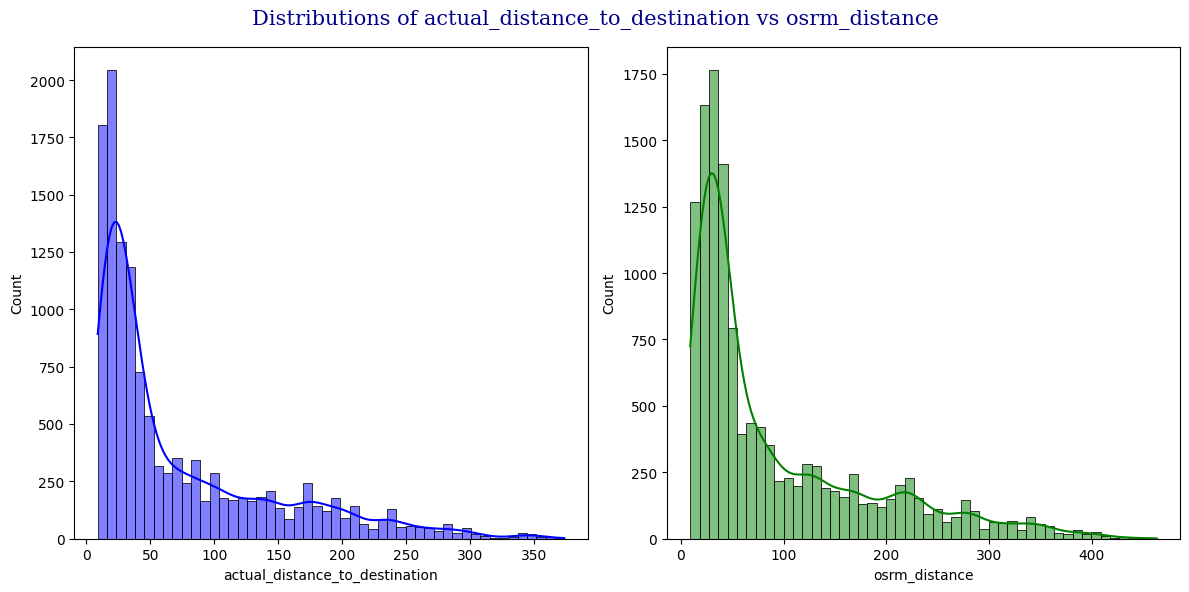

In [152]:
kde_visualization(df,ht_cols)

QQ plot for actual_distance_to_destination:


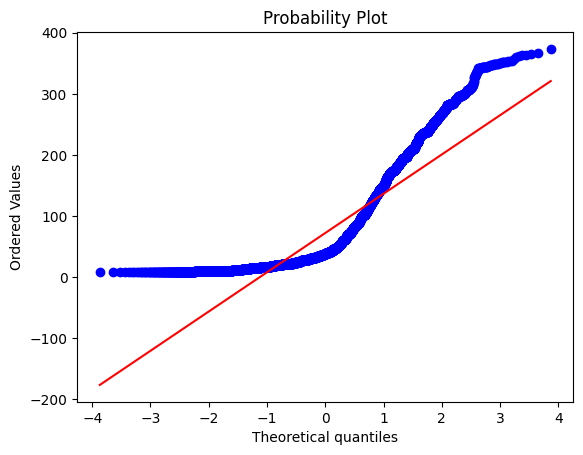

In [154]:
qq_plot(df,ht_cols[0])

QQ plot for osrm_distance:


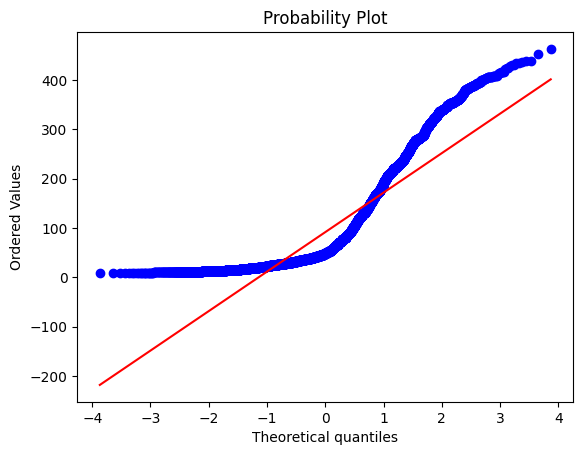

In [156]:
qq_plot(df,ht_cols[1])

In [157]:
levene_test(df, ht_cols)

H0: The variances of the two columns actual_distance_to_destination and osrm_distance are equal
H1: The variances of the two groups are not equal
Levene's test statistic: 216.96069, p-value: 0.0
The variances are not equal (reject H0)


It is clear that these distributions do not have normality and that the variances are unequal. Thus, we perform Mann-Whitney U test instead of T-test.

In [158]:
mann_whitney_u_test(df, ht_cols)

H0: The distributions of the two columns actual_distance_to_destination and osrm_distance are identical
H1: The distributions of the two columns are not identical
Mann-Whitney U test statistic: 68455181.0, p-value: 0.0
The distributions are not identical (reject H0)


> Thus, we find that these two columns - `actual_time` vs `osrm_time` - are in fact dissimilar. This means that the distance predicted by the OSRM model is varying from the actual distance. 

---

## One-Hot Encoding

We encode the fields `route_type` and `data` with one-hot encoding using `LabelEncoder` from `sklearn.preprocessing`

In [159]:
display(df['route_type'].value_counts())

label_encoder = LabelEncoder()
df['route_type'] = label_encoder.fit_transform(df['route_type'])

display(df['route_type'].value_counts())


route_type
Carting    8812
FTL        3911
Name: count, dtype: int64

route_type
0    8812
1    3911
Name: count, dtype: int64

Thus, after one-hot encoding, we have `Carting : 0` and `FTL : 1`

Similarly for `data` as well:

In [160]:
display(df['data'].value_counts())

label_encoder = LabelEncoder()
df['data'] = label_encoder.fit_transform(df['data'])

display(df['data'].value_counts())


data
training    9097
test        3626
Name: count, dtype: int64

data
1    9097
0    3626
Name: count, dtype: int64

Thus, after one-hot encoding, we have `training : 0` and `test : 1`

---

## Standardizing using StandardScaler

We can standardize the numerical columns using `StandardScaler` from `sklearn.preprocessing` :

In [161]:
#creating a copy of df for scaling
df_scaled = df.copy()

In [162]:
scaler = StandardScaler()
scaler.fit(df_scaled[num_cols])


df_scaled[num_cols] = scaler.transform(df_scaled[num_cols])
df_scaled[num_cols].head()

,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
0,-0.548546,-0.544839,0.012060,-0.217856,-0.144341,-0.073948,-0.221500,-0.145358,-0.262662
1,-0.861602,-0.861856,-0.765152,-0.749015,-0.877085,-0.804506,-0.743482,-0.823653,-0.878225
2,1.552838,1.552812,0.764988,1.034163,0.533102,0.614738,1.045260,0.514899,0.365464
3,-0.513328,-0.510150,-0.662169,-0.736369,-0.766482,-0.710888,-0.737116,-0.737295,-0.790288
4,-0.869428,-0.871585,-0.877197,-0.970332,-0.904736,-0.890050,-0.966279,-0.906532,-0.915913


In [163]:
df_scaled[num_cols].describe()

,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
count,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04,1.272300e+04
mean,-1.619566e-17,7.818595e-18,-7.595206e-17,-8.041983e-17,4.467769e-17,3.574215e-17,-3.127438e-17,-8.935537e-17,6.031487e-17
std,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00,1.000039e+00
min,-1.162918e+00,-1.162915e+00,-8.785574e-01,-1.065181e+00,-1.001514e+00,-9.229378e-01,-1.061764e+00,-9.375981e-01,-1.003850e+00
25%,-7.207269e-01,-7.210516e-01,-7.065920e-01,-7.363685e-01,-7.111809e-01,-7.077649e-01,-7.371165e-01,-7.228116e-01,-7.274750e-01
50%,-3.411472e-01,-3.418602e-01,-4.689012e-01,-4.012322e-01,-3.931975e-01,-4.836339e-01,-3.997380e-01,-4.628077e-01,-4.134119e-01
75%,4.023595e-01,4.020802e-01,4.073375e-01,4.650634e-01,4.224989e-01,4.419548e-01,4.596223e-01,4.488499e-01,4.910897e-01
max,4.049455e+00,4.050310e+00,4.178358e+00,4.031419e+00,4.113871e+00,4.150641e+00,4.037107e+00,4.130135e+00,4.046283e+00


In [164]:
#saving the scaled data to a CSV file
df_scaled.to_csv('delhivery_scaled.csv', index=False)

---


## Normalizing using MinMaxScaler

We can also normalize the numerical fields by using `MinMaxScaler` from ` sklearn.preprocessing`

In [165]:
#creating a copy of df for minmax scaling
df_minmax = df.copy()

In [166]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_minmax[num_cols])
df_minmax[num_cols] = pd.DataFrame(df_scaled, columns=num_cols)

df_minmax

,data,trip_creation_time,route_type,trip_uuid,source_name,destination_name,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,...,day,weekday,week,month,source_state,destination_state,source_city,source_place,destination_city,destination_place
0,1,2018-09-12 00:00:22.886430,0,trip-153671042288605164,doddablpur_chikadpp_d (karnataka),doddablpur_chikadpp_d (karnataka),0.117868,0.118559,0.176119,0.166253,...,12,2,37,9,Karnataka,Karnataka,Doddablpur,Chikadpp,Doddablpur,Chikadpp
1,1,2018-09-12 00:01:00.113710,0,trip-153671046011330457,mumbai hub (maharashtra),mumbai_mirard_ip (maharashtra),0.057808,0.057749,0.022426,0.062035,...,12,2,37,9,Maharashtra,Maharashtra,Mumbai,Mumbai Hub,Mumbai,Mirard
2,1,2018-09-12 00:02:09.740725,1,trip-153671052974046625,bellary_dc (karnataka),sandur_wrdn1dpp_d (karnataka),0.521021,0.520930,0.325009,0.411911,...,12,2,37,9,Karnataka,Karnataka,Bellary,Dc,Sandur,Wrdn1Dpp
3,1,2018-09-12 00:02:34.161600,0,trip-153671055416136166,chennai_poonamallee (tamil nadu),chennai_poonamallee (tamil nadu),0.124625,0.125213,0.042791,0.064516,...,12,2,37,9,Tamil Nadu,Tamil Nadu,Chennai,Poonamallee,Chennai,Poonamallee
4,1,2018-09-12 00:04:22.011653,0,trip-153671066201138152,chennai_chrompet_dpc (tamil nadu),chennai_vandalur_dc (tamil nadu),0.056306,0.055883,0.000269,0.018610,...,12,2,37,9,Tamil Nadu,Tamil Nadu,Chennai,Chrompet,Chennai,Vandalur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12718,0,2018-10-03 23:55:56.258533,0,trip-153861095625827784,chandigarh_mehmdpur_h (punjab),chandigarh_mehmdpur_h (punjab),0.175676,0.175846,0.133794,0.091811,...,3,2,40,10,Punjab,Punjab,Chandigarh,Mehmdpur,Chandigarh,Mehmdpur
12719,0,2018-10-03 23:57:23.863155,0,trip-153861104386292051,fbd_balabhgarh_dpc (haryana),faridabad_blbgarh_dc (haryana),0.027778,0.027834,0.017867,0.014888,...,3,2,40,10,Haryana,Haryana,Faridabad,Balabhgarh,Faridabad,Blbgarh
12720,0,2018-10-03 23:57:44.429324,0,trip-153861106442901555,kanpur_govndngr_dc (uttar pradesh),kanpur_govndngr_dc (uttar pradesh),0.298799,0.298859,0.081447,0.338710,...,3,2,40,10,Uttar Pradesh,Uttar Pradesh,Kanpur,Govndngr,Kanpur,Govndngr
12721,0,2018-10-03 23:59:14.390954,0,trip-153861115439069069,tirunelveli_vdkkusrt_i (tamil nadu),tirchchndr_shnmgprm_d (tamil nadu),0.243243,0.243678,0.344973,0.316377,...,3,2,40,10,Tamil Nadu,Tamil Nadu,Tirunelveli,Vdkkusrt,Tirchchndr,Shnmgprm


In [167]:
df_minmax[num_cols].describe()

,start_scan_to_end_scan,od_time_diff_hour,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time_sum,segment_osrm_distance_sum,segment_osrm_time_sum
count,12723.000000,12723.000000,12723.000000,12723.000000,12723.000000,12723.000000,12723.000000,12723.000000,12723.000000
mean,0.223107,0.223070,0.173734,0.208998,0.195785,0.181911,0.208235,0.185013,0.198777
std,0.191859,0.191827,0.197757,0.196217,0.195496,0.197107,0.196130,0.197335,0.198022
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.084835,0.084758,0.034006,0.064516,0.056757,0.042410,0.063670,0.042383,0.054726
50%,0.157658,0.157495,0.081009,0.130273,0.118919,0.086587,0.129838,0.093689,0.116915
75%,0.300300,0.300197,0.254284,0.300248,0.278378,0.269020,0.298377,0.273583,0.296020
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [168]:
# saving the min-max scaled data to a CSV file
df_minmax.to_csv('delhivery_minmax_scaled.csv', index=False)

In [180]:
df.columns

Index(['data', 'trip_creation_time', 'route_type', 'trip_uuid', 'source_name',
       'destination_name', 'start_scan_to_end_scan', 'od_time_diff_hour',
       'actual_distance_to_destination', 'actual_time', 'osrm_time',
       'osrm_distance', 'segment_actual_time_sum', 'segment_osrm_distance_sum',
       'segment_osrm_time_sum', 'hour', 'day', 'weekday', 'week', 'month',
       'source_state', 'destination_state', 'source_city', 'source_place',
       'destination_city', 'destination_place'],
      dtype='object')

### 5. `osrm_distance` vs `segment_osrm_distance_sum`

Setting up hypotheses:

$$H_0 \text{: Means of the two columns are the same.}$$
$$H_0 \text{: Means of the two columns are not the same.}$$



In [183]:
ht_cols=['osrm_distance', 'segment_osrm_distance_sum']

In [184]:
df[ht_cols].mean()

osrm_distance                91.734030
segment_osrm_distance_sum    97.971558
dtype: float64

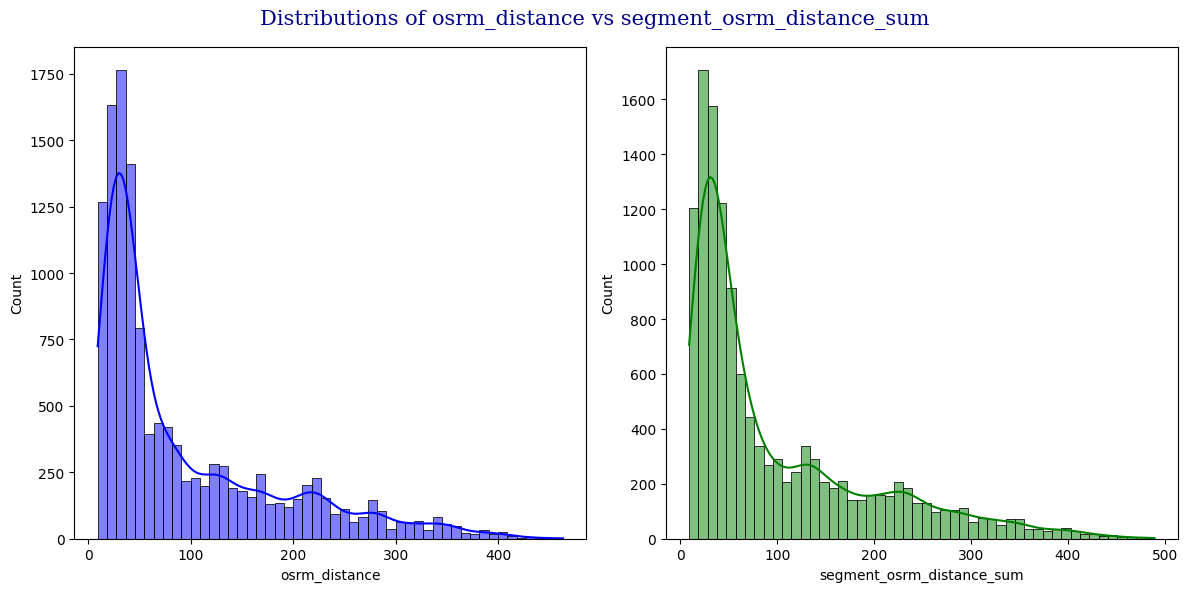

In [186]:
kde_visualization(df,ht_cols)

QQ plot for osrm_distance:


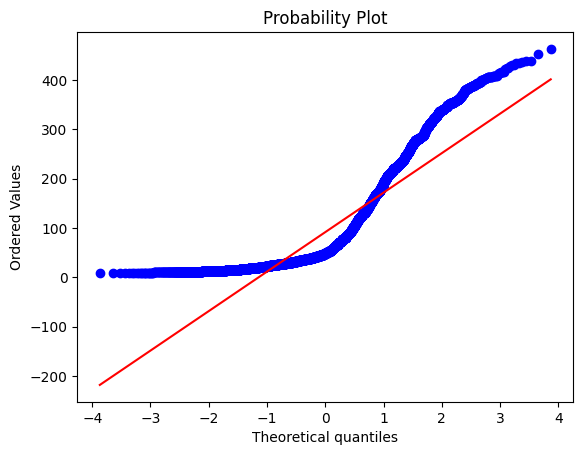

In [187]:
qq_plot(df,ht_cols[0])

QQ plot for segment_osrm_distance_sum:


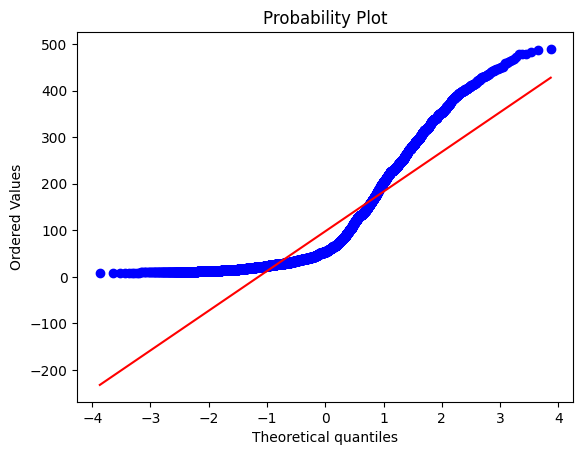

In [188]:
qq_plot(df,ht_cols[1])

In [189]:
levene_test(df, ht_cols)

H0: The variances of the two columns osrm_distance and segment_osrm_distance_sum are equal
H1: The variances of the two groups are not equal
Levene's test statistic: 18.96482, p-value: 1e-05
The variances are not equal (reject H0)


It is clear that these distributions do not have normality nor are the variances equal. Thus, we perform Mann-Whitney U test instead of T-test.

In [190]:
mann_whitney_u_test(df, ht_cols)

H0: The distributions of the two columns osrm_distance and segment_osrm_distance_sum are identical
H1: The distributions of the two columns are not identical
Mann-Whitney U test statistic: 77640596.0, p-value: 0.0
The distributions are not identical (reject H0)


> Thus we find that the two columns have unequal means. THis is interesting because we see that the mean of the `osrm_distance` is lesser than `segment_osrm_distance_sum`!

---

# Insights

- The time period of the data is '2018-09-12' to '2018-10-08' i.e around 26 days.
- After cleaning the data, aggregating, and treating outliers (IQR method) we have data for almost 13000 trips in the above time period.
- 88% of the trips are from September & remaining are from October.
- The entire data is heavily right skewed.
- Most of the features are heavy positively correleated with each other.
- Start & End dates of the months have less percent of trips compare to mid of the month. Though the difference is not huge.
- Thats very strange to see that there is absolutely no trip from 4th- 11th day of the month.
 
- The analysis reveals that a higher proportion of shipments are FTL as opposed to carting. This has important implications for the efficiency and speed of the delivery process.

- Understanding the busiest routes and distances can help in optimizing logistics operations, improving transportation efficiency, and potentially reducing costs. Top 3 source states for inter-state trips are Haryana, Delhi and Maharashtra whereas Haryana, Delhi and Karnataka are the top 3 in terms of being inter-state destinations. 

- Maharashtra, Karnataka and Haryana are not only top source states but also emerge as the top destination states, indicating a high demand or significant business activities in these regions. 

- Bengaluru, Mumbai and Gurgaon are identified as the busiest source cities, suggesting that these cities play a crucial role in contributing to the overall operations. They are also the top destination cities, further indicating their significance to the business.

- Top source cities for intra-state trips are Gurgaon, Pune and Bengalure. Top cities for intra-city ytips are Bengaluru, Mumbai and Chennai.

- Overall, the busiest corridor in terms of interstate trips are Delhi-Haryana, Haryana- Delhi and Haryana-UP. is Mumbai, Maharashtra and Bangalore, Karnataka which has the maximum trips. In terms of maximum trips Nelmangla, Bengaluru to Kgairport, Bengaluru (as well as vice versa) tops the list. The other top place to place corridors are intra-Bilaspur, Gurgaon and another Bangalore corridor from Bomsandra to Bengaluru.

- OSRM Time vs. Actual Time: The difference between the mean values of estimated delivery time (OSRM) and actual delivery time suggests that there are delays or other systemic issues contributing to the actual delivery process compared to the initial estimates.
- The fact that the mean of OSRM time is less than the mean of actual delivery time indicates that the estimated times provided by the OSRM service tend to be at best, very optimistic or completely unrealistic at worst. 

- OSRM Distance vs. Actual Distance: The mean of OSRM distance being greater than the mean of actual distance to the destination suggests that the OSRM might overestimate the distances. This could impact route planning and fuel efficiency calculations.


- Segment-wise time Analysis: The equality in the mean values of actual time and segment actual time suggests that the time measurements are consistent across different segments of the delivery process

- Segment-wise distance Analysis: The mean of segment OSRM distance being greater than the mean of OSRM distance implies that the OSRM might provide more conservative estimates for distance within individual segments. 

- It was seen that there is absolutely no trip from 4th-11th day of the month which is highly unusual, The reason for that can be figured out and catered to.

- FTL route handling system can be implemented more to increase the usage.

-----

## Recommendations

> **Route Optimization:**

   - Busiest state route is within Karnataka, work should be done to improve efficiency and reduce congestion. Consider implementing optimization algorithms and real time traffic monitoring etc.
   - Trips originating from Uttarakhand, Nagaland and Pondicherry have the largest average time taken. Similarly, Tripura, Uttarakhand and Goa take the longest to receive packages. The terrain in these regions need to be taken into account when optimizing further.
   - Since Gurgaon and Bangalore are identified as two of the source and destination cities, we should have city-specific strategies to manage their high volume of trips. 
   

> **Operational Efficiency:**

   - Since mean of OSRM time is less than the mean of actual delivery time, we should set more realistic delivery time in order to not have innaccurate customer expectations.
   - Since the mean of OSRM distance greater than the mean of actual distance, we should adjusting the distance estimations to facilitate more accurate planning.
   - Implement advanced demand forecasting techniques to anticipate peak travel times and adjust transportation services accordingly. This proactive approach can help in better resource allocation and minimize the impact of congestion during peak hours.
   -  A strategic decision can be made to pivot to more FTL over carting as this can improve efficiency. 
   - Overall, the analysis hints at potential areas for operational improvement such as refining route planning algorithms, addressing discrepancies in estimated times and distances, and streamlining different stages of delivery to enhance overall operational efficiency.
 
 
> **Customer Satisfaction:**

   - As mentioned already, by improving accuracy in estimated delivery times and distances we can customer satisfaction by managing their expectations. 
   - Faster delivery times can directly impact customer satisfaction. Customers value timely deliveries, as this aligns with meeting or exceeding customer expectations in terms of shipment speed.
    
 
> **Collaborations:**

   - Collaborate with other relevant stakeholders, including government authorities, transportation companies, and local communities, to develop and implement comprehensive strategies for managing and optimizing transportation in the identified busy corridors and cities.
     
---